In [1]:
import sys

import numpy as np
import pandas as pd
import arviz as az

from math import sqrt

from collections import defaultdict

from scipy.stats import truncnorm, norm, truncexpon
from scipy.linalg import inv, cholesky
from scipy.optimize import linprog
import scipy.interpolate as si

from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

import os
import pickle
import pyreadr

import networkx as nx

from joblib import Parallel, delayed 
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns


### Global Variables and Classes

In [2]:
# Global variables
IMAGE_DIR = os.path.join(os.path.abspath(os.path.join(os.getcwd(), "..")), "Images")
RESULT_DIR = os.path.join(os.path.abspath(os.path.join(os.getcwd(), "..")), "Results")
CONSTRAINT_DIR = os.path.join(os.path.abspath(os.path.join(os.getcwd(), "..")), "Constraints") 
DATA_DIR = os.path.join(os.path.abspath(os.path.join(os.getcwd(), "..")), "Data_Application")
print(f"Images will be saved in: {IMAGE_DIR}")
print(f"Results will be saved in: {RESULT_DIR}")
print(f"Constraints will be saved in: {CONSTRAINT_DIR}")
print(f"Data will be loaded from: {DATA_DIR}")

Images will be saved in: /Users/zhengyu/Desktop/UF/Research/Intergral_Linear_Programming/Images
Results will be saved in: /Users/zhengyu/Desktop/UF/Research/Intergral_Linear_Programming/Results
Constraints will be saved in: /Users/zhengyu/Desktop/UF/Research/Intergral_Linear_Programming/Constraints
Data will be loaded from: /Users/zhengyu/Desktop/UF/Research/Intergral_Linear_Programming/Data_Application


In [3]:
class GenData:
    def __init__(self, n, d=2, p=1, m=None,
                 X=None, method_gen_X=None, 
                 beta=None, method_gen_beta=None, rank_beta=3,
                 constraint=None, gen_constraint=False,
                 prob_func=None, seed=None):
        """
        Initialize the GenData class.

        Parameters:
        ----------
        n : int
            Number of data points to generate.
        d : int, optional
            Dimensionality of each data point (default is 2).
        p : int, optional
            Number of predictors (default is 1).
        X : numpy.ndarray or None, optional
            Design matrix of shape (p, n). If None, X is generated randomly.
        method_gen_X : str or None, optional
            Method for generating the design matrix if X is None:
            - "random": Generate a random normal matrix (default).
            - "orthonormal": Generate an orthonormal matrix.
            - "BSpline": Generate a B-spline basis matrix.
            - None: Defaults to "random".
        beta : numpy.ndarray or None, optional
            Coefficient matrix of shape (d, p). If None, β is generated randomly.
        method_gen_beta : str or None, optional
            Method for generating the coefficient matrix beta if beta is None:
            - "low_rank": Generate a low-rank matrix.
            - None: Generate a random normal matrix (default).
        rank_beta : int, optional
            Rank of the low-rank matrix if method_gen_beta is "low_rank" (default is 3).
        constraint : dict or None, optional
            Dictionary with keys 'A' and 'b', representing the constraint A y <= b.
            'A' is an m x d matrix, and 'b' is an m-dimensional vector.
        prob_func : callable, optional
            Custom probability function for generating binary outcomes. Defaults to the sigmoid function.
        seed : int or None, optional
            Random seed for reproducibility. Defaults to None (no fixed seed).
        """
        self.seed = seed
        if self.seed is not None:
            np.random.seed(self.seed)  # Set the seed for reproducibility

        self.n = n
        self.d = d
        self.p = p

        # Generate X based on method_gen_X
        if X is not None:
            self.X = X
        elif method_gen_X == "orthonormal":
            self.X = self._generate_orthonormal_design_matrix(p, n)
        elif method_gen_X == "BSpline":
            self.X = self.generate_spline_basis(n, p)/10
        else:  # Default to random normal
            self.X = np.random.randn(p, n)

        if constraint is None and gen_constraint:
            if m is None:
                raise ValueError("The number of constraints 'm' must be provided when asked to generate constraints.")
            self.m = m
            self.constraint = self._generate_constraint()
        else:
            self.constraint = constraint
            self.m = constraint.get('A').shape[0] if constraint else None

        self.beta = self._generate_beta(method=method_gen_beta, k=rank_beta) if beta is None else beta
        self.prob_func = prob_func if prob_func is not None else lambda x: 1 / (1 + np.exp(-x))
        self.y = None
        self.linear_predictor = None

        # Validate dimensions
        if self.X.shape != (self.p, self.n):
            raise ValueError(f"X must have shape ({self.p}, {self.n}).")
        if self.beta.shape != (self.d, self.p):
            raise ValueError(f"beta must have shape ({self.d}, {self.p}).")
        if self.constraint is not None:
            A = self.constraint.get('A')
            b = self.constraint.get('b')
            if A.shape[1] != self.d:
                raise ValueError(f"Matrix A must have {self.d} columns to match the dimension of y.")
            if len(b) != A.shape[0]:
                raise ValueError("The length of vector b must match the number of rows in matrix A.")

    def _generate_orthonormal_design_matrix(self, p, n):
        """
        Generate an orthonormal design matrix of size (p, n).
        """
        if p > n:
            raise ValueError("The number of rows (p) cannot exceed the number of columns (n) for orthonormality.")
        random_matrix = np.random.randn(n, n)
        Q, _ = np.linalg.qr(random_matrix)
        return Q[:p, :]

    
    def _generate_beta(self, method=None, k=3):
        """
        Generate the coefficient matrix beta based on the specified method.

        Parameters:
        ----------
        method : str or None, optional
            Method for generating beta:
            - "low_rank": Generate a low-rank matrix with rank k.
            - None: Generate a random normal matrix (default).
        k : int, optional
            Rank of the low-rank matrix (default is 3).
        """
        if method == "low_rank":
            U = np.random.randn(self.d, k)
            V = np.random.randn(self.p, k)
            return U @ V.T
        else:
            return np.random.randn(self.d, self.p)
        

    @staticmethod
    def generate_network_tum_matrix(m, d):
        """
        Generate a totally unimodular matrix based on a random directed graph.

        Parameters:
        -----------
        m : int
            Number of edges (rows).
        d : int
            Number of nodes (columns).

        Returns:
        --------
        np.ndarray
            A totally unimodular matrix of shape (m, d).
        """
        if d < 2 or m < d - 1:
            raise ValueError("Ensure sufficient edges for connectivity.")

        # Generate a random directed acyclic graph (DAG)
        G = nx.gnm_random_graph(d, m, directed=True)

        # Compute the node-arc incidence matrix
        A = np.zeros((m, d), dtype=int)
        edge_list = list(G.edges())

        for i, (u, v) in enumerate(edge_list):
            A[i, u] = -1  # Outgoing from node u
            A[i, v] = 1   # Incoming to node v

        return A



    

    def _generate_constraint(self):
        """
        Generates:
        - A: Directed incidence matrix of shape (m, d)
        - b: A vector of shape (m,) with all zeros

        A is an incidence matrix representing a directed graph where each row corresponds to
        a constraint (edge), and each column corresponds to a variable (node).
        """
        if self.d*self.m <= 50:
            # Use rejection sampling for TUM matrix
            is_tum = False
            while not is_tum:
                A = np.random.choice([-1, 0, 1], size=(self.m, self.d), p=[0.25,0.5,0.25])
                # Check if there is any row that is all zero
                if not np.all(np.abs(A).sum(axis=1)>0):
                    continue
                is_tum = self.is_totally_unimodular_ortools(A)
            return {'A': A, 'b': np.ones(self.m)}
        
        return {'A': self.simulate_totally_unimodular_A(self.m, self.d),
                'b': self.simulate_binary_vector(self.m)}
    


        # while True:
        #     # Initialize an empty A matrix
        #     A = np.zeros((self.m, self.d))

        #     # Randomly generate directed edges
        #     for i in range(self.m):
        #         # Randomly pick two distinct columns (nodes) to form a directed edge
        #         node_indices = np.random.choice(self.d, size=2, replace=False)

        #         # Set incidence matrix values: +1 for the starting node, -1 for the ending node
        #         A[i, node_indices[0]] = 1
        #         A[i, node_indices[1]] = -1

        #         # Check for duplicate constraints
        #         for j in range(i):
        #             if np.array_equal(A[i], A[j]):
        #                 A[i, :] = 0
        #                 # Randomly pick two distinct columns (nodes) to form a directed edge
        #                 node_indices = np.random.choice(self.d, size=2, replace=False)

        #                 # Set incidence matrix values: +1 for the starting node, -1 for the ending node
        #                 A[i, node_indices[0]] = 1
        #                 A[i, node_indices[1]] = -1
        #                 break

        #     no_duplicates = True
        #     for i in range(self.m):
        #         for j in range(i):
        #             if np.array_equal(A[i], A[j]):
        #                 no_duplicates = False
        #                 break
        #     if no_duplicates:
        #             break

                        
        # # Generate a random binary vector b of shape (m,)
        # b = np.zeros(self.m)
        

        # # A = self.generate_network_tum_matrix(self.m, self.d)
        # # b = np.zeros(self.m)
        # # b[0] = 1
        # # b[-1] = -1
        

        # return {'A': A, 'b': b}
    

    def add_constraint(self, A_new, b_new):
        """
        Add a new constraint to the existing constraint matrix A and vector b.

        Parameters:
        ----------
        A_new : numpy.ndarray
            New constraint matrix of shape (m_new, d).
        b_new : numpy.ndarray
            New constraint vector of shape (m_new,).
        """
        if self.constraint is None:
            self.constraint = {'A': A_new, 'b': b_new}
            print("No existing constraint found. Added new constraint.")
        if A_new.shape[1] != self.d:
            raise ValueError("The number of columns in A_new must match the dimension of y.")
        if len(b_new) != A_new.shape[0]:
            raise ValueError("The length of b_new must match the number of rows in A_new.")

        A = np.vstack((self.constraint.get('A'), A_new))
        b = np.concatenate((self.constraint.get('b'), b_new))

        # Update m and constraint
        self.m = A.shape[0]
        self.constraint = {'A': A, 'b': b}


    @staticmethod
    def simulate_totally_unimodular_A(m, d, seed=None):
        """
        Simulate an m x d totally unimodular matrix.
        Each row will have exactly one +1 and one -1 (and zeros elsewhere),
        which is a common structure for incidence matrices of directed graphs.
        """
        if seed is not None:
            np.random.seed(seed)
        A = np.zeros((m, d))
        for i in range(m):
            # Randomly choose two distinct indices from 0 to d-1.
            j1, j2 = np.random.choice(d, size=2, replace=False)
            A[i, j1] = 1
            A[i, j2] = -1
        return A
    

    @staticmethod
    def simulate_binary_vector(m, seed=None):
        """
        Simulate a binary vector of length m.
        """
        if seed is not None:
            np.random.seed(seed + 100)  # offset seed for variety
        return np.random.randint(0, 2, size=m)  
    






    def compute_linear_predictor(self):
        """
        Compute the linear predictor based on X and beta.
        """
        self.linear_predictor = (self.beta @ self.X).T  # Shape: (n x d)

    
    def solve_linear_programming(self, eta):
        """
        Solve the linear programming problem to obtain the optimal z:
        max_z eta^T z subject to Az <= b and z ∈ {0, 1}^d

        Parameters:
        ----------
        eta : numpy.ndarray
            The latent variable eta.
        
        Returns:
        -------
        z_opt : numpy.ndarray
            The optimal binary vector z.
        """
        if self.constraint:
            # Solve max_z eta^T z subject to Az <= b and z ∈ {0, 1}^d
            res = linprog(c=-eta,  # Negate for maximization
                          A_ub=self.constraint.get('A'), 
                          b_ub=np.array(self.constraint.get('b')), 
                          bounds=[(0, 1)] * self.d,  # Binary constraints relaxed to [0, 1]
                          method="highs")
            if res.success:
                z_opt = np.round(res.x).astype(int)
            else:
                print("Linear programming failed.")
                sys.exit(1)
        else:
            # If no constraints, simply threshold eta_i
            z_opt = (eta > 0).astype(int)

        return z_opt


    def generate_data(self, verbose=False, method="default", eta_variance=1.0):
        """
        Generate the data y using the specified method, subject to constraints if provided.

        Parameters:
        ----------
        verbose : bool, optional
            If True, prints progress during data generation (default is False).
        method : str, optional
            The method to generate data. Options are:
            - "default": Binary sampling based on probabilities.
            - "latent": Generate latent variables eta and solve optimization problem for y.
        eta_variance : float, optional
            Variance of the latent variable eta when using the "latent" method (default is 1.0).

        Returns:
        -------
        data : dict
            Dictionary containing:
            - "y": Generated data of shape (n, d).
            - "X": Design matrix of shape (p, n).
            - "constraint": The provided constraint (if any).
        """

        if self.seed is not None:
            np.random.seed(self.seed)  # Set the seed for reproducibility

        self.compute_linear_predictor()
        self.y = np.zeros((self.n, self.d), dtype=int)

        if method == "default":
            # Default method: Binary sampling based on probabilities
            if self.constraint is None:
                for i in range(self.n):
                    if verbose:
                        print(f"Generating data for row {i+1}/{self.n}...")
                    probs = self.prob_func(self.linear_predictor[i])
                    self.y[i] = (np.random.rand(self.d) < probs).astype(int)
            else:
                A = np.array(self.constraint.get('A'))
                b = np.array(self.constraint.get('b'))

                def generate_row(i):
                    while True:
                        probs = self.prob_func(self.linear_predictor[i])
                        y_i = (np.random.rand(self.d) < probs).astype(int)
                        if np.all(A @ y_i <= b):
                            return y_i

                self.y = np.array(Parallel(n_jobs=-1)(delayed(generate_row)(i) for i in range(self.n)))

        elif method == "latent":
            eta = self.linear_predictor + np.random.normal(scale=eta_variance, size=(self.n, self.d))
            # Latent variable method
            A = np.array(self.constraint.get('A')) if self.constraint else None
            b = np.array(self.constraint.get('b')) if self.constraint else None

            for i in range(self.n):
                if verbose:
                    print(f"Generating data for row {i+1}/{self.n}...")
                self.y[i] = self.solve_linear_programming(eta[i])

        else:
            raise ValueError(f"Unknown generation method '{method}'. Use 'default' or 'latent'.")

        return {"y": self.y, "X": self.X, "constraint": self.constraint}
    

    
    @staticmethod
    def generate_spline_basis(T, p, num_basis=5, degree=3):
        """
        Generates a B-spline basis matrix of shape (p, T).

        Parameters:
        ----------
        T : int
            Number of time points.
        p : int
            Dimensionality of the covariates
        num_basis : int
            Number of basis functions to generate.
        degree : int, optional
            Degree of the B-spline basis functions (default is 3).

        Returns:
        ----------
        basis_matrix : numpy.ndarray
            B-spline basis matrix of shape (p, T).
        """
        time_points = np.linspace(0, 1, T)  # Normalized time points

        # Construct B-spline basis functions
        basis_matrix = np.zeros((p, T))
        for i in range(p):
            basis_funcs = si.BSpline(np.linspace(0, 1, num_basis+degree+1), 
                                     np.random.randn(num_basis), 
                                     degree)
            basis_matrix[i, :] = basis_funcs(time_points)

        return basis_matrix
    
    

    def get_summary(self):
        """
        Generate a summary of the generated data and constraints.

        Returns:
        -------
        summary : str
            A string summarizing the key properties of the generated data.
        """
        summary = f"Data Summary:\n"
        summary += f"  - Number of observations (n): {self.n}\n"
        summary += f"  - Dimensionality of responses (d): {self.d}\n"
        summary += f"  - Number of predictors (p): {self.p}\n"
        summary += f"  - Constraint applied: {'Yes' if self.constraint else 'No'}\n"
        if self.constraint:
            summary += f"  - Constraint shape: A({self.constraint['A'].shape}), b({len(self.constraint['b'])})\n"
        return summary

    def save_data(self, filename):
        """
        Save the generated data to a file.

        Parameters:
        ----------
        filename : str
            Path to the file where the data will be saved.
        """
        data = {"X": self.X, "y": self.y, "constraint": self.constraint}
        np.savez(filename, **data)

    @staticmethod
    def load_data(filename):
        """
        Load generated data from a file.

        Parameters:
        ----------
        filename : str
            Path to the file from which the data will be loaded.

        Returns:
        -------
        data : dict
            A dictionary containing the loaded data.
        """
        with np.load(filename) as data:
            return {key: data[key] for key in data}
    


In [4]:
class Updater:
    def __init__(self, data, tau, constraint):
        """
        Initialize the Updater class.

        Parameters:
        ----------
        data : dict
            Dictionary containing:
            - "X" : numpy.ndarray, shape (p, n)
                Design matrix (features).
            - "y" : numpy.ndarray, shape (n, d)
                Binary response matrix.
        tau : float
            Precision parameter for beta's prior distribution.
        constraint : dict
            Dictionary containing:
            - "A": numpy.ndarray, shape (m, d)
                Constraint matrix (required).
            - "b": numpy.ndarray, shape (m,)
                Constraint thresholds (optional).
        """
        # Extract data and validate inputs
        self.X = data.get("X")  # Design matrix (p x n)
        if self.X is None:
            raise ValueError("Data must contain a design matrix 'X'.")
        self.y = data.get("y")  # Binary response matrix (n x d)
        if self.y is None:
            raise ValueError("Data must contain a response matrix 'y'.")

        self.constraint = constraint
        self.tau = tau  # Precision parameter

        # Extract and validate constraints
        self.A = constraint.get("A")  # Constraint matrix (m x d)
        if self.A is None:
            raise ValueError("Constraint dictionary must contain a matrix 'A'.")
        self.b = constraint.get("b", None)  # Optional thresholds

        # Dimensionality validation
        if self.X.shape[1] != self.y.shape[0]:
            raise ValueError("The number of columns in X must match the number of rows in y.")
        if self.A.shape[1] != self.y.shape[1]:
            raise ValueError("The number of columns in A must match the number of columns in y.")


        # Store dimensions for convenience
        self.p, self.n = self.X.shape  # p: number of predictors, n: number of observations
        self.n, self.d = self.y.shape  # n: number of observations, d: number of response variables
        self.m, _ = self.A.shape  # m: number of constraints
        self.n_red = None  # number of non-interior points y_i

        # Store some transformations of y
        self.y_shifted = self.y - 0.5  # 0 -> -0.5, 1 -> 0.5
        self.tilde_y = 1 - 2 * self.y   # 0 -> 1, 1 -> -1

        # Initialize cached values
        self.XXt = None  # Cache for XX'
        self.covariance_inv = None  # Cache for (XX' + I_p / tau)^{-1}
        self.covariance_inv_cholesky = None  # Cache for the cholesky decomposition of (XX' + I_p / tau)^{-1}
        self.active_set = None  # Active set for constraints
        self.r = None  # Direction corrector r_k=1(k in active set)
        self.interior_y = None # Interior point y
        self.A_y = None  # Matrices A adjusted by y_i
        self.init_beta = None # Initial beta
        self.init_u = None  # Augmented variable
        self.init_zeta = None  # Initial zeta

        # Precompute reusable values and initialize components
        self._precompute_covariance_inv()
        self._precompute_active_set()
        self._precompute_r()
        self._precompute_interior_y()
        self._precompute_A_y()
        self._init_beta()
        self._init_u()
        self._init_zeta()
        





    def _precompute_covariance_inv(self):
        """
        Precompute and cache (XX' + I_p / tau)^{-1} and its Cholesky decomposition.

        Updates:
        -------
        self.XXt : numpy.ndarray, shape (p, p)
            Cached matrix XX', where X is the design matrix.
        self.covariance_inv : numpy.ndarray, shape (p, p)
            Cached inverse of (XX' + I_p / tau).
        self.covariance_inv_cholesky : numpy.ndarray, shape (p, p)
            Cached Cholesky decomposition of the inverse covariance matrix.
        """
        self.XXt = self.X @ self.X.T  # Compute XX' (shape: p x p)
        covariance = self.XXt + np.eye(self.p) / self.tau  # XX' + I_p / tau (shape: p x p)
        self.covariance_inv = inv(covariance)  # Compute the inverse (shape: p x p)
        self.covariance_inv_cholesky = cholesky(self.covariance_inv, lower=True)  # Cholesky decomposition of the inverse




    def _precompute_active_set(self):
        """
        Precompute the active set for each data point based on the constraints.

        The active set contains indices of constraints that are "active," meaning
        they are satisfied as equalities for each row of y.

        Updates:
        -------
        self.active_set : list of sets
            Each set contains the indices of active constraints for the corresponding row of y.
        """
        self.active_set = []  # Initialize the active set list (length: n)

        for i in range(self.n):
            active_row = set()  # Active constraints for the i-th row of y
            Ay = self.A @ self.y[i]  # Compute A y for the i-th row (shape: m,)

            if self.b is not None:
                # Find indices where Ay is close to b (active constraints)
                active_row = {j for j in range(self.m) if np.isclose(Ay[j], self.b[j])}

            self.active_set.append(active_row)  # Append the active set for row i

        # Ensure all active set entries are integers
        for i in range(self.n):
            self.active_set[i] = set(map(int, self.active_set[i]))

        for i in range(self.n):
            if not all(isinstance(j, int) for j in self.active_set[i]):
                raise ValueError(f"Active set for row {i} contains non-integer indices: {self.active_set[i]}")



    def _precompute_r(self):
        """
        Precompute the binary mask r for all observations.

        Updates:
        -------
        self.r : numpy.ndarray, shape (n, m)
            Binary matrix where r[i, k] = 1 if k ∈ active_set[i], else 0.
        """
        self.r = np.zeros((self.n, self.m), dtype=int) # Initialize r as a binary matrix
        for i, active_indices in enumerate(self.active_set):
            self.r[i, list(active_indices)] = 1

    def _precompute_interior_y(self):
        self.interior_y = np.sum(self.r, axis=1) == 0  # Interior points have no active constraints
        self.n_red = self.n - np.sum(self.interior_y)  # Number of non-interior points

    
    def _precompute_A_y(self):
        list_A_y = np.zeros((self.n, self.m, self.d))  # Initialize A_y as a 3D array
        for i in range(self.n):
            list_A_y[i] = self.A * (2*self.y[i] - 1)  # Adjust the matrices A based on y_i
        self.A_y = list_A_y  # Store the adjusted matrices A_y
             

    def _init_beta(self):
        self.init_beta = np.random.randn(self.d, self.p)  # Initialize beta with random values (shape: d x p)


    def _init_u(self):
        """
        Initialize u based on the active set.

        Updates:
        -------
        self.u : numpy.ndarray, shape (n, m)
            Initialized matrix where:
            - u_{ij} = 0 for inactive constraints.
            - u_{ij} ~ Exponential(1) for active constraints.
        """
        self.init_u = np.random.exponential(scale=1.0, size=(self.n, self.m)) * self.r  # Sample from Exponential(1) for active constraints




    def _init_zeta(self):
        """
        Initialize zeta based on the values of y.

        Updates:
        -------
        self.zeta : numpy.ndarray, shape (n, d)
            Matrix of shape (n, d) where:
            - If y_{ij} = 1, then zeta_{ij} is sampled from a truncated normal distribution.
            - If y_{ij} = 0, then zeta_{ij} is sampled from a truncated normal distribution.
        """
        # Compute UA
        UA = self.init_u @ self.A  # Shape: n by d
        linear_predictor = self.X.T @ self.init_beta.T  # Shape: n by d


        self.init_zeta = np.where(self.y == 1, 
                                  truncnorm.rvs(a=UA-linear_predictor, b=np.inf, loc=linear_predictor, scale=1, size=(self.n, self.d)),
                                  truncnorm.rvs(a=-np.inf, b=UA-linear_predictor, loc=linear_predictor, scale=1, size=(self.n, self.d)))




    def update_zeta(self, u=None, beta=None, UA=None, linear_predictor=None):
        """
        Update zeta using a truncated normal distribution.

        zeta is an (n, d) matrix. Each element \( \zeta_{ij} \) is sampled from a truncated normal
        distribution with mean \( \mu_{ij} \) (computed as \( (\beta X)^T \)) and variance 1. The truncation
        bounds are determined by the observed data \( y \) and the threshold matrix \( uA \), where \( A \)
        is from the constraint.

        At least one of u or UA must be provided.
        At least one of beta or linear_predictor must be provided.

        Parameters:
        ----------
        zeta : numpy.ndarray, shape (n, d)
            Matrix of constraints to be updated.
        u : numpy.ndarray, shape (n, m), optional
            Threshold matrix for the constraint. 
            If None, must provide UA.
        beta : numpy.ndarray, shape (d, p), optional
            Coefficient matrix where each row corresponds to a feature and each column to a predictor.
            If None, must provide linear_predictor.
        UA : numpy.ndarray, shape (n, d), optional
            Product of the threshold matrix \( u \) and the constraint matrix \( A \).
            If None, computes \( uA \) internally.
        linear_predictor : numpy.ndarray, shape (n, d), optional
            Linear predictor matrix where each row corresponds to a feature and each column to a predictor.
            If None, computes the linear predictor internally.

        Returns:
        -------
        new_zeta : numpy.ndarray, shape (n, d)
            Updated zeta matrix, where \( \zeta_{ij} \) is sampled from a truncated normal distribution
            with mean \( \mu_{ij} \) and variance 1, truncated according to the observed data \( y \)
            and threshold matrix \( uA \).
        """
        if u is None and UA is None:
            raise ValueError("Either u or UA must be provided.")
        if beta is None and linear_predictor is None:
            raise ValueError("Either beta or linear_predictor must be provided.")


        # Compute only the required parts of mu and uA
        if linear_predictor is not None:
            mu_J = linear_predictor
        else:
            mu_J = self.X.T @ beta.T  # Shape: n by |J|

        
        if UA is not None:
            uA_J = UA
        else:
            uA_J = u @ self.A

        # Compute truncation bounds for the specified columns
        lower_bound = np.where(self.y == 1, uA_J, -np.inf)  # If y_ij == 1, truncate below uA_ij
        upper_bound = np.where(self.y == 0, uA_J, np.inf)   # If y_ij == 0, truncate above uA_ij

        # Standardize the bounds for truncnorm
        a_std = (lower_bound - mu_J)  # Lower bound standardized
        b_std = (upper_bound - mu_J)  # Upper bound standardized

        # Efficient sampling for the specified elements
        new_zeta = truncnorm.rvs(a=a_std, b=b_std, loc=mu_J, scale=1, size=mu_J.shape)

        return new_zeta
    


    def update_zeta_unconstrained_simple_example(self, beta):
        mu = self.X.T @ beta.T
        # Compute truncation bounds for the specified columns
        lower_bound = np.where(self.y == 1, 0, -np.inf)  # If y_ij == 1, truncate below 0
        upper_bound = np.where(self.y == 0, 0, np.inf)   # If y_ij == 0, truncate above 0

        # Standardize the bounds for truncnorm
        a_std = (lower_bound - mu)  # Lower bound standardized
        b_std = (upper_bound - mu)  # Upper bound standardized

        # Efficient sampling for the specified elements
        new_zeta = truncnorm.rvs(a=a_std, b=b_std, loc=mu, scale=1, size=mu.shape)

        return new_zeta
    
    



    def acceptance_probabilities(self, uA_J, ustarA_J, mu_J, y_J):
        """
        Compute the acceptance probability for Metropolis-Hastings.

        Parameters:
        ----------
        uA_J : ndarray, shape (n, |J|)
            Current values of the threshold matrix for the current state.
        ustarA_J : ndarray, shape (n, |J|)
            Proposed values of the threshold matrix for the proposed state.
        mu_J : ndarray, shape (n, |J|)
            Mean values for the truncated normal distribution.
        y_J : ndarray, shape (n, |J|)
            Binary response matrix for the current state.

        Returns:
        -------
        alpha : ndarray, shape (n,)
            Acceptance probabilities for the proposed state.
        """
        # Precompute common terms
        diff_uA = uA_J - mu_J
        diff_ustarA = ustarA_J - mu_J

        # Compute cuts based on y_J
        cuts = np.where(y_J == 1, -diff_uA, diff_uA)
        cuts_star = np.where(y_J == 1, -diff_ustarA, diff_ustarA)

        # Avoid recalculating CDFs by leveraging broadcasting efficiently
        cdf_cuts = norm.cdf(cuts)
        cdf_cuts_star = norm.cdf(cuts_star)

        # Clip very small CDF values to avoid numerical instability
        cdf_cuts = np.clip(cdf_cuts, 1e-10, None)
        cdf_cuts_star = np.clip(cdf_cuts_star, 1e-10, None)

        # Compute element-wise acceptance ratios
        alpha_elements = cdf_cuts / cdf_cuts_star

        # Aggregate alpha for each row using the product of elements
        alpha = np.exp(np.sum(np.log(alpha_elements), axis=1))  # Product via log-sum-exp
        

        return alpha

    





    def u_in_U_y_zeta(self, zeta, UA, U, J=None):
        """
        Check if the matrix u is within the region U_{y, zeta} for each row.

        Here we assume U[i, non_active_i] = 0 for each i.

        Parameters:
        ----------
        zeta : ndarray, shape (n, d)
            Matrix of constraints.
        UA : ndarray, shape (n, d)
            Matrix representing the product U @ A for the current state.
        U : ndarray, shape (n, m)
            Matrix to be checked against constraints.
        J : list, optional
            Indices of features to update. If None, updates all features.

        Returns:
        -------
        in_region : ndarray, shape (n,)
            Boolean array indicating whether each row of u satisfies the constraints.
        """
        # Compute the difference between zeta and UA
        diff = zeta - UA

        # Check if all elements satisfy the tilde_y * diff <= 0 constraint
        if J is not None:
            satisfies_tilde_y_constraints = np.all(self.tilde_y[:,J] * diff <= 0, axis=1)
        else:
            satisfies_tilde_y_constraints = np.all(self.tilde_y * diff <= 0, axis=1)        

        # Check if all elements of U are non-negative
        non_negative_constraints = np.all(U >= 0, axis=1)

        # Combine constraints
        in_region = satisfies_tilde_y_constraints & non_negative_constraints

        return in_region






    def update_zeta_and_u(self, zeta, u, beta, J=None, nested_iter=5, simple_example=False):
        """
        Jointly update zeta and u using Metropolis-Hastings.

        Parameters:
        ----------
        beta : ndarray
            Coefficient matrix of shape (d, p).
        zeta : ndarray
            Current zeta matrix of shape (n, d).
        u : ndarray
            Current u matrix of shape (n, m).
        J : list, optional
            Indices of features to update. If None, updates all features.
        nested_iter : int, optional
            Number of nested iterations for updating u. Default is 30.

        Returns:
        -------
        zeta : ndarray
            Updated zeta matrix.
        u : ndarray
            Updated u matrix.
        accept : ndarray
            Boolean array of shape (n,) indicating which rows were accepted.
        """
        if J is None:
            J = list(range(self.d))  # Default: update all features

        # Get a copy of the current zeta and u
        cur_zeta = np.copy(zeta)
        cur_u = np.copy(u)

        # Update zeta and compute required components
        zeta, mu_J, uA_J, y_J = self.update_zeta(zeta=cur_zeta, u=cur_u, beta=beta, J=J)

        # Propose a new state for u (Uniform distribution over U_{y_i, zeta_i})
        if simple_example:
            u = self.update_u_simple_example(zeta)
        else:
            # Perform nested updates for u
            for _ in range(nested_iter):
                u = self.update_u(zeta, u)
        

        # Compute ustarA_J
        ustarA_J = u @ self.A[:, J]

        # Compute acceptance probabilities
        acceptance_rate = self.acceptance_probabilities(uA_J, ustarA_J, mu_J, y_J)
        acceptance_rate *= self.u_in_U_y_zeta(cur_zeta[:, J], ustarA_J, u, J)

        
        

        # Accept or reject the proposed state
        accept = np.random.rand(self.n) < acceptance_rate

        # Update zeta and u based on acceptance
        zeta = np.where(accept[:, None], zeta, cur_zeta)
        u = np.where(accept[:, None], u, cur_u)

        return zeta, u, accept

    



    def update_zeta_with_u_auxiliary(self, mu_u, std_u, zeta, linear_predictor):
        # Step 1: Generate u | y, mu from q(u | y, mu)
        u = np.where(self.r, np.random.normal(loc=mu_u, scale=std_u, size=(self.n, self.m)), 0)
        # u = np.where(self.r, np.random.exponential(scale=np.divide(1, mu_u, out=np.zeros_like(mu_u), where=mu_u!=0), size=(self.n, self.m)), 0) # Exponential
        
        UA = u @ self.A  # Compute UA
        u_in_region = self.u_in_U_y_zeta(zeta=zeta, UA=UA, U=u, J=list(range(self.d)))

        All_in_region = np.all(u_in_region)
        max_iter = 100

        while not All_in_region and max_iter > 0:
            u = np.where(u_in_region[:, None], u, np.where(self.r, np.random.normal(loc=mu_u, scale=std_u, size=(self.n, self.m)), 0))
            UA = u @ self.A  # Compute UA
            u_in_region = self.u_in_U_y_zeta(zeta=zeta, UA=UA, U=u, J=list(range(self.d)))

            All_in_region = np.all(u_in_region)
            max_iter -= 1
            if max_iter == 0:
                print(f"Max iteration reached with number of rows not in region: {np.sum(~u_in_region)}")
                
          
        
        # Step 2: Update zeta
        # zeta = np.where(u_in_region[:, None], 
        #                 self.update_zeta(zeta=zeta, UA=UA, linear_predictor=linear_predictor)[0], 
        #                 zeta)
        zeta = self.update_zeta(zeta=zeta, UA=UA, linear_predictor=linear_predictor)[0]
        
        
        return zeta, u_in_region
        
    

   


    def update_u_simple_example(self, zeta):
        """
        Update U for a simple example.

        Parameters:
        ----------
        zeta : ndarray, shape (n, d)
            Matrix of constraints.

        Returns:
        -------
        U : ndarray, shape (n, m)
            Updated U matrix.
        """
        U = np.zeros((self.n, self.m))

        # Conditions for different y configurations
        condition_2 = (self.y[:, 0] == 0) & (self.y[:, 1] == 1)  # y_i = (0, 1)
        condition_3 = (self.y[:, 0] == 1) & (self.y[:, 1] == 0)  # y_i = (1, 0)

        # Update U for condition_2
        U[condition_2, 0] = (
            np.random.rand(np.sum(condition_2)) *
            (zeta[condition_2, 1] - np.maximum(zeta[condition_2, 0], 0)) +
            np.maximum(zeta[condition_2, 0], 0)
        )

        # Update U for condition_3
        U[condition_3, 0] = (
            np.random.rand(np.sum(condition_3)) *
            (zeta[condition_3, 0] - np.maximum(zeta[condition_3, 1], 0)) +
            np.maximum(zeta[condition_3, 1], 0)
        )

        return U

   
    

    def update_zeta_and_u_simple_example(self, zeta, u, beta):
        """
        Jointly update zeta and U for a simple example.

        Parameters:
        ----------
        zeta : ndarray, shape (n, d)
            Current zeta matrix.
        u : ndarray, shape (n, m)
            Current U matrix.
        beta : ndarray, shape (d, p)
            Coefficient matrix.

        Returns:
        -------
        zeta : ndarray, shape (n, d)
            Updated zeta matrix.
        u : ndarray, shape (n, m)
            Updated U matrix.
        accept : ndarray, shape (n,)
            Boolean array indicating which rows were accepted.
        """
        # Get copies of the current state
        cur_u = np.copy(u)
        cur_zeta = np.copy(zeta)

        # Conditions for different y configurations
        condition_2 = (self.y[:, 0] == 0) & (self.y[:, 1] == 1)  # y_i = (0, 1)
        condition_3 = (self.y[:, 0] == 1) & (self.y[:, 1] == 0)  # y_i = (1, 0)

        # Compute mu
        mu = (beta @ self.X).T  # Shape: (n, d)

        # Update zeta
        zeta = self.update_zeta_for_simple_example_fix_u(beta, zeta, u)

        # Update u
        u = self.update_u_simple_example(zeta)

        # Compute acceptance probabilities
        cuts = self.tilde_y * (cur_u @ self.A - mu)
        cuts_star = self.tilde_y * (u @ self.A - mu)

        alpha_elements = norm.cdf(cuts) / norm.cdf(cuts_star)

        # Aggregate acceptance rates for each row
        acceptance_rates = np.prod(alpha_elements, axis=1)

        # Include additional constraints for condition_2 and condition_3
        acceptance_rates[condition_2] *= (
            (cur_zeta[condition_2, 1] > u[condition_2, 0]) &
            (u[condition_2, 0] > np.maximum(cur_zeta[condition_2, 0], 0))
        )
        acceptance_rates[condition_3] *= (
            (cur_zeta[condition_3, 0] > u[condition_3, 0]) &
            (u[condition_3, 0] > np.maximum(cur_zeta[condition_3, 1], 0))
        )

        # Accept or reject proposed states
        accept = np.random.rand(self.n) < acceptance_rates

        # Update zeta and u based on acceptance
        zeta = np.where(accept[:, None], zeta, cur_zeta)
        u = np.where(accept[:, None], u, cur_u)

        return zeta, u, accept


    
        






    def update_zeta_for_simple_example(self, beta, zeta):
        """
        Update zeta based on the y matrix and truncated normal distribution rules.

        Parameters:
        ----------
        beta : numpy.ndarray, shape (d, p)
            Coefficient matrix.
        zeta : numpy.ndarray, shape (n, d)
            Current zeta values to be updated.

        Returns:
        -------
        zeta : numpy.ndarray, shape (n, d)
            Updated zeta values.
        """
        mu = (beta @ self.X).T  # Shape: n by d

        # Define conditions based on y values
        condition_1 = (self.y[:, 0] == 0) & (self.y[:, 1] == 0)  # y_i = (0, 0)
        condition_2 = (self.y[:, 0] == 0) & (self.y[:, 1] == 1)  # y_i = (0, 1)
        condition_3 = (self.y[:, 0] == 1) & (self.y[:, 1] == 0)  # y_i = (1, 0)

        # Case 1: Both zeta_1 < 0 and zeta_2 < 0 -> y_i = (0, 0)
        zeta[condition_1, :] = truncnorm.rvs(
            a=-np.inf,
            b=-mu[condition_1, :],
            loc=mu[condition_1, :],
            scale=1,
            size=zeta[condition_1, :].shape
        )

        # Case 2: zeta_1 < zeta_2 and zeta_2 > 0 -> y_i = (0, 1)
        lower_bound = np.maximum(zeta[condition_2, 0], 0)  # Ensure zeta_2 > 0
        zeta[condition_2, 1] = truncnorm.rvs(
            a=lower_bound - mu[condition_2, 1],
            b=np.inf,
            loc=mu[condition_2, 1],
            scale=1,
            size=zeta[condition_2, 1].shape
        )
        zeta[condition_2, 0] = truncnorm.rvs(
            a=-np.inf,
            b=zeta[condition_2, 1] - mu[condition_2, 0],
            loc=mu[condition_2, 0],
            scale=1,
            size=zeta[condition_2, 0].shape
        )

        # Case 3: zeta_1 > zeta_2 and zeta_1 > 0 -> y_i = (1, 0)
        zeta[condition_3, 1] = truncnorm.rvs(
            a=-np.inf,
            b=zeta[condition_3, 0] - mu[condition_3, 1],
            loc=mu[condition_3, 1],
            scale=1,
            size=zeta[condition_3, 1].shape
        )
        lower_bound = np.maximum(zeta[condition_3, 1], 0)  # Ensure zeta_1 > 0
        zeta[condition_3, 0] = truncnorm.rvs(
            a=lower_bound - mu[condition_3, 0],
            b=np.inf,
            loc=mu[condition_3, 0],
            scale=1,
            size=zeta[condition_3, 0].shape
        )

        return zeta




    def update_zeta_for_simple_example_fix_u(self, beta, zeta, u):
        """
        Given u, update zeta for the simple example
        """
        mu = (beta @ self.X).T  # Shape: n by d

        condition_1 = (self.y[:,0]==0) & (self.y[:,1]==0)   # y_i=(0,0)
        condition_2 = (self.y[:,0]==0) & (self.y[:,1]==1)  # y_i=(0,1)
        condition_3 = (self.y[:,0]==1) & (self.y[:,1]==0)  # y_i=(1,0)


        # Both zeta_1 < 0 and zeta_2 < 0 -> y_i=(0,0)
        zeta[condition_1,:] = truncnorm.rvs(a=-np.inf,
                                            b=-mu[condition_1,:],
                                            loc=mu[condition_1,:],
                                            scale=1,
                                            size=zeta[condition_1,:].shape)

        # zeta_1 < zeta_2 and zeta_2 > 0 -> y_i=(0,1)
        zeta[condition_2,1] = truncnorm.rvs(a=u[condition_2,0]-mu[condition_2,1],
                                            b=np.inf,
                                            loc=mu[condition_2,1],
                                            scale=1,
                                            size=zeta[condition_2,1].shape)
        zeta[condition_2,0] = truncnorm.rvs(a=-np.inf,
                                            b=u[condition_2,0]-mu[condition_2,0],
                                            loc=mu[condition_2,0],
                                            scale=1,
                                            size=zeta[condition_2,0].shape)

        # zeta_1 > zeta_2 and zeta_1 > 0 -> y_i=(1,0)
        zeta[condition_3,1] = truncnorm.rvs(a=-np.inf,
                                            b=u[condition_3,0]-mu[condition_3,1],
                                            loc=mu[condition_3,1],
                                            scale=1,
                                            size=zeta[condition_3,1].shape)
        zeta[condition_3,0] = truncnorm.rvs(a=u[condition_3,0]-mu[condition_3,0],
                                            b=np.inf,
                                            loc=mu[condition_3,0],
                                            scale=1,
                                            size=zeta[condition_3,0].shape)

        return zeta






    def update_beta(self, zeta):
        """
        Update beta from the matrix normal distribution.

        Returns:
        -------
        beta : numpy.ndarray, shape (d, p)
            Updated coefficient matrix sampled from the posterior matrix normal distribution.
        """
        # Compute the mean of beta: zeta' X' covariance_inv
        mean_beta = zeta.T @ self.X.T @ self.covariance_inv  # Shape: (d, p)

        # Sample from Mat-N(mean_beta, I_d, covariance_inv)
        beta = mean_beta + np.random.normal(size=(self.d, self.p)) @ self.covariance_inv_cholesky.T  # Shape: (d, p)

        return beta
    











    def update_u(self, zeta, u):
        """
        Update u using the hit-and-run algorithm with parallel processing.

        Parameters:
        ----------
        zeta : numpy.ndarray, shape (n, d)
            Auxiliary variable matrix where each row corresponds to an observation.
        u : numpy.ndarray, shape (n, m)
            Current value of the augmented variable to be updated.

        Returns:
        -------
        u : numpy.ndarray, shape (n, m)
            Updated augmented variable, sampled uniformly from U_{y_i, zeta_i}
            for each row u^{(i)} of u.
        """
        if zeta.shape[0] != self.n or u.shape[0] != self.n:
            raise ValueError("The number of rows in zeta and u must match self.n.")

        # Generate random directions for all rows
        q = np.random.normal(size=(self.n, self.m))
        # q /= np.linalg.norm(q, axis=1, keepdims=True)  # Normalize each row to make unit vectors
        q *= self.r  # Apply active set masks (Hadamard product)

        # Compute some quantities used for determining lambda_min and lambda_max
        UA = u @ self.A  # Shape: (n, d)
        QA = q @ self.A  # Shape: (n, d)
        zeta_minus_UA_over_QA = np.divide(zeta - UA, QA, out=np.zeros_like(QA), where=QA != 0)  # Avoid division by zero
        neg_U_over_Q = np.divide(-u, q, out=np.zeros_like(q), where=q != 0)  # Avoid division by zero

        upper_bound1 = np.where(
            ((QA > 0) & (self.y == 1)) | ((QA < 0) & (self.y == 0)),
            zeta_minus_UA_over_QA,
            np.inf 
        )
        lower_bound1 = np.where(
            ((QA < 0) & (self.y == 1)) | ((QA > 0) & (self.y == 0)),
            zeta_minus_UA_over_QA,
            -np.inf
        )

        upper_bound2 = np.where(
            q < 0,
            neg_U_over_Q,
            np.inf
        )
        lower_bound2 = np.where(
            q > 0,
            neg_U_over_Q,
            -np.inf
        )

        lambda_min = np.maximum(np.max(lower_bound1, axis=1), np.max(lower_bound2, axis=1))
        lambda_max = np.minimum(np.min(upper_bound1, axis=1), np.min(upper_bound2, axis=1))

        # Handle invalid intervals
        invalid_mask = lambda_min >= lambda_max
        lambda_min[invalid_mask] = 0
        lambda_max[invalid_mask] = 0

        # Sample step sizes
        t = np.random.uniform(lambda_min, lambda_max)  # Shape: (n,)
        t = np.expand_dims(t, axis=1)  # Expand to match the shape of q

        # Update u
        u_new = u + t * q
        
        return u_new
    


    def update_u_using_SVM(self, zeta):
        mu_U = np.zeros((self.n, self.m))  # Initialize mu_U matrix
        std_U = np.ones((self.n, self.m))  # Initialize std_U matrix

        A_T = self.A.T  # Transpose once instead of repeatedly calling .T

        for i in range(self.n):
            # Extract active set indices as a NumPy array (faster slicing)
            active_set_indices = np.array(list(self.active_set[i]), dtype=int)
            
            # Stack matrices directly without unnecessary conversions
            tilde_A = np.vstack((self.A[active_set_indices], -zeta[i, :]))
            
            # Use LinearSVC instead of SVC(kernel='linear') for speed
            clf = LinearSVC(dual=False, max_iter=10000, fit_intercept=False, C=1e+5)  # dual=False is better for n_samples > n_features
            clf.fit(tilde_A.T, self.tilde_y[i])

            # Extract and normalize coefficient
            u = clf.coef_[0]
            
            # Normalize u so that the last component is 1
            u_adjusted = u[:-1] / u[-1] # if u[-1] != 0 else u[:-1]

            # Efficiently update mu_U
            mu_U[i, active_set_indices] = u_adjusted

            # Compute margin error efficiently
            # A_selected = self.A[active_set_indices]  # Avoid redundant indexing
            # margin_error = np.divide(
            #     zeta[i, :] - np.dot(u_adjusted, A_selected),
            #     np.dot(np.ones(len(active_set_indices)), A_selected)
            # )
            margin_error = np.abs(zeta[i, :] - np.dot(u_adjusted, self.A[active_set_indices]))

            # Efficiently compute std_U
            std_U[i, active_set_indices] = np.min(margin_error) / 3

        return mu_U, std_U

    


    def update_u_using_linear_programming(self, zeta):
        mu_U = np.zeros((self.n, self.m))
        std_U = np.ones((self.n, self.m))

        for i in range(self.n):
            active_set_indices = np.array(list(self.active_set[i]), dtype=int)
            tilde_A_ub = self.A_y[i][active_set_indices, :].T
            b_ub = zeta[i, :] * (-self.tilde_y[i])
            c = np.zeros(len(active_set_indices))
            mu_U[i, active_set_indices] = linprog(c, A_ub=tilde_A_ub, b_ub=b_ub).x

        return mu_U, std_U      
    



    def generate_u_from_exp_kernel_hit_and_run(self, zeta, u, rho=1.0):
        # The input u must be in U_{y, zeta} for each row
        if zeta.shape[0] != self.n or u.shape[0] != self.n:
            raise ValueError("The number of rows in zeta and u must match self.n.")
    

        # Generate random directions for all rows
        q = np.random.normal(size=(self.n, self.m))
        q *= self.r  # Apply active set masks (Hadamard product)
        q_norm = np.linalg.norm(q, axis=1)

        # Identify rows that need to be updated
        mask = ~np.logical_or(q_norm > 1e-12, self.interior_y)  # Find rows where condition is False

        while np.any(mask):  # Keep looping while at least one row needs an update
            q[mask] = np.random.normal(size=(np.sum(mask), self.m))  # Update only the selected rows
            q[mask] *= self.r[mask]  # Apply active set masks only to updated rows
            q_norm[mask] = np.linalg.norm(q[mask], axis=1)  # Recompute norms for updated rows
            mask = ~np.logical_or(q_norm > 1e-12, self.interior_y)  # Recalculate mask

        # Normalize each row to make unit vectors
        q = np.divide(q, q_norm[:, None], out=np.zeros_like(q), where=q_norm[:, None] != 0)

        # Compute some quantities used for determining lambda_min and lambda_max
        UA = u @ self.A  # Shape: (n, d)
        QA = q @ self.A  # Shape: (n, d)
        zeta_minus_UA_over_QA = np.divide(zeta - UA, QA, out=np.zeros_like(QA), where=QA!=0)  # Avoid division by zero
        neg_U_over_Q = np.divide(-u, q, out=np.zeros_like(q), where=q!=0)  # Avoid division by zero

        upper_bound1 = np.where(
            ((QA > 0) & (self.y == 1)) | ((QA < 0) & (self.y == 0)),
            zeta_minus_UA_over_QA,
            np.inf 
        )
        lower_bound1 = np.where(
            ((QA < 0) & (self.y == 1)) | ((QA > 0) & (self.y == 0)),
            zeta_minus_UA_over_QA,
            -np.inf
        )

        upper_bound2 = np.where(
            q < 0,
            neg_U_over_Q,
            np.inf
        )
        lower_bound2 = np.where(
            q > 0,
            neg_U_over_Q,
            -np.inf
        )

        lambda_min = np.maximum(np.max(lower_bound1, axis=1), np.max(lower_bound2, axis=1))
        lambda_max = np.minimum(np.min(upper_bound1, axis=1), np.min(upper_bound2, axis=1))

        # Cut lambda_min and lambda_max for infinite bounds
        lambda_min = np.where(lambda_min == -np.inf, -1e12, lambda_min)
        lambda_max = np.where(lambda_max == np.inf, 1e12, lambda_max)

        if not np.all(lambda_min < lambda_max + 1e-30):
            print("Warning: Some rows have invalid intervals.")
            

        rate_q = q.sum(axis=1)  # Compute the rate of the exponential distribution
        c = - rate_q * rho
        u_rand = np.random.uniform(0, 1, size=self.n)
        
        t = np.where(
            np.abs(rate_q) < 1e-12,
            lambda_min + u_rand * (lambda_max - lambda_min),
            np.divide(1.0, c, out=np.zeros_like(c), where=c!=0) * np.log(np.exp(c * lambda_min) + u_rand * (np.exp(c * lambda_max) - np.exp(c * lambda_min)))
        )
        

        # Update u
        u_new = u + t[:, None] * q
        
        return u_new
    



    def find_tilde_zeta(self, zeta, zeta_star):
        """
        Compute tilde_zeta based on conditions:
        - If y_{ij} = 1 → tilde_zeta_{ij} = max(zeta_{ij}, zeta_star_{ij})
        - If y_{ij} = 0 → tilde_zeta_{ij} = min(zeta_{ij}, zeta_star_{ij})

        Parameters:
        - zeta: (n, m) NumPy array
        - zeta_star: (n, m) NumPy array

        Returns:
        - tilde_zeta: (n, m) NumPy array with computed values
        """            
        return np.where(self.y == 1, np.maximum(zeta, zeta_star), np.minimum(zeta, zeta_star))
    


    def update_zeta_using_two_u(self, zeta, u, beta, nested_iter=[30, 30]):
        # Step 1: Use hit-and-run to generate u
        for _ in range(nested_iter[0]):
            u = self.generate_u_from_exp_kernel_hit_and_run(zeta, u)
            if not np.all(self.u_in_U_y_zeta(zeta, u@self.A, u)):
                print("Warning: Some rows are not in the region U_y_zeta.")
                break
        
        # Step 2: Propose zeta_star
        zeta_star = self.update_zeta(u=u, beta=beta)

        # Step 3: Find tilde_zeta and u_star
        tilde_zeta = self.find_tilde_zeta(zeta, zeta_star)
        u_star = self.generate_u_from_exp_kernel_hit_and_run(tilde_zeta, u)
        for _ in range(nested_iter[1]-1):
            u_star = self.generate_u_from_exp_kernel_hit_and_run(tilde_zeta, u_star)

        # Step 4: Decide if to accept or reject the proposal
        UA_star = u_star @ self.A
        u_star_in_region = self.u_in_U_y_zeta(zeta, UA_star, u_star)
        
        return np.where(u_star_in_region[:, None], zeta_star, zeta), u, u_star_in_region

            
            

    










    

    def update_zeta_using_SVM_u_given_plus_set(self, zeta, linear_predictor,
                                            class_weights=None, C=1e5, tol=1e-2, max_iter=10000, n_jobs=-1, epsilon=1e-4):
        """
        Update zeta using SVM U given the plus set.

        Parameters:
        ----------
        zeta : ndarray
            Current zeta matrix of shape (n, d).
        linear_predictor : ndarray
            Linear predictor matrix of shape (n, d).
        class_weights : dict, optional
            Class weights for the SVM. Defaults to {-1: 1e10, 1: 1}.
        C : float
            Regularization parameter for the SVM.
        tol : float
            Tolerance for the SVM solver.
        max_iter : int
            Maximum number of iterations for the SVM solver.
        n_jobs : int
            Number of parallel jobs to run. Defaults to -1 (use all available cores).
        epsilon : float
            Small positive value to ensure non-negativity of u_adjusted.

        Returns:
        -------
        zeta : ndarray
            Updated zeta matrix of shape (n, d).
        """
        if class_weights is None:
            class_weights = {-1: 1e10, 1: 1}


        def sample_truncated_normal(mean, upper_bound):
            """Sample from a truncated normal distribution."""
            a, b = -np.inf, (upper_bound - mean)
            return truncnorm(a, b, loc=mean, scale=1).rvs()

        def update_zeta_for_row(i, zeta, linear_predictor, class_weights, C, tol, max_iter, epsilon):
            """Update zeta for a single row."""
            # Get plus set and minus set indices
            plus_set_indices = np.where(self.y[i] == 1)[0]
            minus_set_indices = np.where(self.y[i] == 0)[0]

            # Check if plus set is empty
            if minus_set_indices.size == 0:
              return zeta[i]

            # Check if active set or plus set is empty
            if not self.active_set[i] or plus_set_indices.size == 0:  # Use .size to check emptiness
                zeta[i, minus_set_indices] = sample_truncated_normal(linear_predictor[i, minus_set_indices], 0)
                return zeta[i]


            # Compute tilde_zeta and tilde_y for the row
            tilde_zeta = self.y[i] * zeta[i] + (1 - self.y[i]) * linear_predictor[i]
            tilde_y = 1 - 2 * self.y[i]

            # Extract active set indices
            active_set_indices = list(self.active_set[i])
            tilde_A = np.vstack((self.A[active_set_indices], tilde_zeta[np.newaxis, :]))
            n_active = len(active_set_indices)

            try:
                # Fit the SVM model
                svm_model = LinearSVC(
                    C=C,
                    fit_intercept=False,
                    class_weight=class_weights,
                    dual=True,
                    tol=tol,
                    max_iter=max_iter
                )
                svm_model.fit(tilde_A.T, tilde_y)
            except Exception as e:
                print(f"Error fitting SVM for row {i}: {e}")
                return zeta[i]

            # Extract the coefficient
            u = svm_model.coef_[0]
            # u_adjusted = u[:-1] / (-u[-1])  # No adjustment other than rescaling
            # u_adjusted = np.maximum(u_adjusted, 0)

            verification = tilde_y * np.dot(tilde_A.T, u)
            min_verification = np.min(verification[plus_set_indices])
            # Adjust u
            u_adjusted = (u[:-1] + np.full(n_active, min_verification / n_active)) / (-u[-1]) # SOMETHING WRONG
            u_adjusted = np.maximum(u_adjusted, 0)

            # # Check non-negativity of u_adjusted
            # if np.any(u_adjusted < -epsilon):
            #     return zeta[i]  # Keep current zeta if condition not met

            # Compute UA for minus set
            UA_row = np.zeros(self.d)
            UA_row[minus_set_indices] = np.dot(u_adjusted, self.A[np.ix_(active_set_indices, minus_set_indices)])



            # Vectorized update for zeta in the minus set
            if np.all(zeta[i, minus_set_indices] <= UA_row[minus_set_indices]):
                trunc_means = linear_predictor[i, minus_set_indices]
                trunc_upper_bounds = UA_row[minus_set_indices]
                zeta[i, minus_set_indices] = sample_truncated_normal(trunc_means, trunc_upper_bounds)

            return zeta[i]

        # Parallel computation
        updated_zeta = Parallel(n_jobs=n_jobs)(
            delayed(update_zeta_for_row)(i, zeta, linear_predictor, class_weights, C, tol, max_iter, epsilon)
            for i in range(self.n)
        )


        # Collect results
        return np.array(updated_zeta)




    def update_zeta_using_SVM_u_given_minus_set(self, zeta, linear_predictor,
                                             class_weights=None, C=1e5, tol=1e-2, max_iter=10000, n_jobs=-1, epsilon=1e-4):
        """
        Update zeta using SVM U given the minus set.

        Parameters:
        ----------
        zeta : ndarray
            Current zeta matrix of shape (n, d).
        linear_predictor : ndarray
            Linear predictor matrix of shape (n, d).
        class_weights : dict, optional
            Class weights for the SVM. Defaults to {-1: 1, 1: 1e10}.
        C : float
            Regularization parameter for the SVM.
        tol : float
            Tolerance for the SVM solver.
        max_iter : int
            Maximum number of iterations for the SVM solver.
        n_jobs : int
            Number of parallel jobs to run. Defaults to -1 (use all available cores).
        epsilon : float
            Small positive value to ensure non-negativity of u_adjusted.

        Returns:
        -------
        zeta : ndarray
            Updated zeta matrix of shape (n, d).
        """
        if class_weights is None:
            class_weights = {-1: 1, 1: 1e10}

        def sample_truncated_normal(mean, lower_bound):
            """Sample from a truncated normal distribution."""
            a, b = (lower_bound - mean), np.inf
            return truncnorm(a, b, loc=mean, scale=1).rvs()

        def update_zeta_for_row(i, zeta, linear_predictor, class_weights, C, tol, max_iter, epsilon):
            """Update zeta for a single row."""
            # Get plus set and minus set indices
            plus_set_indices = np.where(self.y[i] == 1)[0]
            minus_set_indices = np.where(self.y[i] == 0)[0]

            # Check if plus set is empty
            if plus_set_indices.size == 0:
              return zeta[i]

            # Check if active set or minus set is empty
            if not self.active_set[i] or minus_set_indices.size == 0:  # Use .size to check emptiness
                zeta[i, plus_set_indices] = sample_truncated_normal(linear_predictor[i, plus_set_indices], 0)
                return zeta[i]


            # Compute tilde_zeta and tilde_y for the row
            tilde_zeta = self.y[i] * linear_predictor[i] + (1 - self.y[i]) * zeta[i]
            tilde_y = 1 - 2 * self.y[i]

            # Extract active set indices
            active_set_indices = list(self.active_set[i])
            tilde_A = np.vstack((self.A[active_set_indices], tilde_zeta[np.newaxis, :]))
            n_active = len(active_set_indices)

            try:
                # Fit the SVM model
                svm_model = LinearSVC(
                    C=C,
                    fit_intercept=False,
                    class_weight=class_weights,
                    dual=True,
                    tol=tol,
                    max_iter=max_iter
                )
                svm_model.fit(tilde_A.T, tilde_y)
            except Exception as e:
                print(f"Error fitting SVM for row {i}: {e}")
                return zeta[i]

            # Extract the coefficient
            u = svm_model.coef_[0]
            # u_adjusted = u[:-1] / (-u[-1])  # No adjustment other than rescaling
            # u_adjusted = np.maximum(u_adjusted, 0)

            verification = tilde_y * np.dot(tilde_A.T, u)
            min_verification = np.min(verification[minus_set_indices])
            # Adjust u
            u_adjusted = (u[:-1] - np.full(n_active, min_verification / n_active)) / (-u[-1]) # SOMETHING WRONG
            u_adjusted = np.maximum(u_adjusted, 0)

            # # Check non-negativity of u_adjusted
            # if np.any(u_adjusted < -epsilon):
            #     return zeta[i]  # Keep current zeta if condition not met

            # Compute UA for plus set
            UA_row = np.zeros(self.d)
            UA_row[plus_set_indices] = np.dot(u_adjusted, self.A[np.ix_(active_set_indices, plus_set_indices)])

            # Vectorized update for zeta in the plus set
            if np.all(zeta[i, plus_set_indices] >= UA_row[plus_set_indices]):
                trunc_means = linear_predictor[i, plus_set_indices]
                trunc_lower_bounds = UA_row[plus_set_indices]
                zeta[i, plus_set_indices] = sample_truncated_normal(trunc_means, trunc_lower_bounds)

            return zeta[i]

        # Parallel computation
        updated_zeta = Parallel(n_jobs=n_jobs)(
            delayed(update_zeta_for_row)(i, zeta, linear_predictor, class_weights, C, tol, max_iter, epsilon)
            for i in range(self.n)
        )

        # Collect results
        return np.array(updated_zeta)
    

    @staticmethod
    def truncated_exponential(rate=1, trunc=5, size=1):
        """
        Generate truncated exponential random variables using the rate parameter.

        Parameters:
        - rate: Rate parameter (λ) of the exponential distribution (default: 1).
        - trunc: Upper truncation point.
        - size: Number of samples.

        Returns:
        - Array of truncated exponential random variables.
        """
        scale = 1 / rate  # Convert rate to scale
        b = trunc * rate  # Since b = trunc / scale = trunc * rate

        return truncexpon(b=b, scale=scale).rvs(size=size)

    



    













In [5]:
class MCMCAnalysis:
    def __init__(self, samples, burn_in=0, param_name=None, ground_truth=None):
        """
        Initialize the MCMCAnalysis class.

        Parameters:
        ----------
        samples : numpy.ndarray
            MCMC samples of shape (n_iterations, dim1, dim2), where:
            - n_iterations: Number of MCMC iterations.
            - dim1: First dimension (e.g., response dimensions).
            - dim2: Second dimension (e.g., predictors or parameters).
        burn_in : int, optional
            Number of initial iterations to discard as burn-in (default is 0).
        param_name : str, optional
            Name of the parameter being analyzed (e.g., "beta", "zeta", "u"). Default is None.
        """
        # Validate input dimensions
        if not isinstance(samples, np.ndarray):
            raise ValueError("Samples must be a numpy array.")
        if samples.ndim != 3:
            raise ValueError("Samples must have three dimensions: (n_iterations, dim1, dim2).")

        # Store raw samples and post burn-in samples
        self.raw_samples = samples  # All samples including burn-in
        self.burn_in = burn_in
        if burn_in >= samples.shape[0]:
            raise ValueError("Burn-in must be less than the number of iterations.")
        self.samples = samples[burn_in:]  # Post burn-in samples

        # Store dimensions
        self.n_iterations, self.dim1, self.dim2 = self.samples.shape

        # Store parameter name
        self.param_name = param_name if param_name else "Parameter"

        # Store ground truth if available
        self.ground_truth = ground_truth

        # Print initialization details
        print(f"Initialized MCMCAnalysis for {self.param_name}:")
        print(f"- Total iterations: {samples.shape[0]}")
        print(f"- Burn-in: {burn_in}")
        print(f"- Post burn-in iterations: {self.n_iterations}")
        print(f"- Dimension 1 (dim1): {self.dim1}")
        print(f"- Dimension 2 (dim2): {self.dim2}")




    



    def posterior_means(self):
        """
        Compute the posterior mean of each parameter.

        Returns:
        -------
        posterior_means : numpy.ndarray
            Posterior mean of shape (dim1, dim2).
        """
        return np.mean(self.samples, axis=0)
    


    def MSE(self):
        """
        Compute the Mean Squared Error (MSE) between the posterior means and the ground truth.

        Parameters:
        ----------
        ground_truth : numpy.ndarray
            The ground truth parameter values of shape (dim1, dim2).

        Returns:
        -------
        mse : float
            The Mean Squared Error between the posterior means and the ground truth.
        """
        if self.ground_truth is None:
            raise ValueError("Ground truth is required to compute MSE.")
        
        posterior_means = self.posterior_means()

        # Validate dimensions
        if self.ground_truth.shape != posterior_means.shape:
            raise ValueError(
                f"Dimension mismatch: ground_truth has shape {self.ground_truth.shape}, "
                f"but posterior means have shape {posterior_means.shape}."
            )

        # Compute MSE
        mse = np.mean((posterior_means - self.ground_truth) ** 2)
        return mse
    


    def gelman_rubin(self):
        """
        Compute the Gelman-Rubin diagnostic (R-hat) for convergence assessment.

        Returns:
        -------
        rhat_values : numpy.ndarray
            R-hat values for each parameter of shape (dim1, dim2).
        """
        rhat_values = np.zeros((self.dim1, self.dim2))
        for i in range(self.dim1):
            for j in range(self.dim2):
                rhat_values[i, j] = az.rhat(self.samples[:, i, j])
        return rhat_values



    def posterior_distributions(self, bins=30):
        """
        Plot the posterior distributions for all parameters.

        Parameters:
        ----------
        bins : int, optional
            Number of bins for the histogram (default is 30).
        """
        fig, axes = plt.subplots(self.dim1, self.dim2, figsize=(15, 5 * self.dim1), sharex=False, sharey=False)

        if self.dim2 == 1:
            axes = np.expand_dims(axes, axis=-1)
        if self.dim1 == 1:
            axes = np.expand_dims(axes, axis=0)

        fig.suptitle(f"Posterior Distributions of {self.param_name} Samples", fontsize=16)

        for i in range(self.dim1):
            for j in range(self.dim2):
                ax = axes[i, j] if (self.dim1 > 1 and self.dim2 > 1) else axes[max(i, j)]
                ax.hist(self.samples[:, i, j], bins=bins, alpha=0.7, label=f"{self.param_name}[{i},{j}]")
                ax.set_title(f"{self.param_name}[{i},{j}]", fontsize=12)
                ax.set_xlabel("Value", fontsize=10)
                ax.set_ylabel("Frequency", fontsize=10)
                ax.legend()

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


    
    def effective_sample_size(self):
        """
        Compute the effective sample size (ESS) for each parameter.

        Returns:
        -------
        ess_values : numpy.ndarray
            Effective sample size for each parameter of shape (dim1, dim2).
        """
        ess_values = np.zeros((self.dim1, self.dim2))
        for i in range(self.dim1):
            for j in range(self.dim2):
                ess_values[i, j] = az.ess(self.samples[:, i, j])
        return ess_values
    




    def plot_trace_single_param(self, idx, plot_ground_truth=True, save_path=None):
        """
        Plot the trace plot for a single parameter.

        Parameters:
        ----------
        idx : tuple
            Index of the parameter to plot (dim1, dim2).
        ground_truth : numpy.ndarray, optional
            Ground truth value of the parameter at the specified index. If provided, a horizontal line is plotted.
        save_path : str, optional
            Path to save the plot as an image file (e.g., "trace_plot.png"). If None, the plot is displayed.
        """
        if not isinstance(idx, tuple) or len(idx) != 2:
            raise ValueError("Index must be a tuple of (dim1, dim2).")

        dim1, dim2 = idx
        plt.figure(figsize=(12, 6))
        plt.plot(range(self.n_iterations), self.samples[:, dim1, dim2], alpha=0.8)
        # Add a horizontal line afor the ground truth if available
        if plot_ground_truth and self.ground_truth is not None:
            plt.axhline(self.ground_truth[dim1, dim2], color='red', linestyle='--', label="Ground Truth")

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to {save_path}")
        else:
            plt.show()





    def trace_plots(self, max_dim1=10, max_dim2=10, config=1, param_indices=[(0, 0)], 
                    save_path=None, clean_mode=False):
        """
        Plot the trace plots for all parameters.

        Parameters:
        ----------
        max_dim1 : int, optional
            Maximum number of plots for the first dimension (default is 10).
        max_dim2 : int, optional
            Maximum number of plots for the second dimension (default is 10).
        config : int, optional
            Config 1: Individual trace plots for each parameter.
            Config 2: Single plot with all traces of selected parameters.
        param_indices : list of tuples, optional (for config==2)
            List of (dim1, dim2) index pairs specifying which parameters to plot (default is [(0,0)]).
        ground_truth : np.ndarray, optional
            Ground truth values of shape (dim1, dim2). If provided, a vertical line is plotted at the ground truth.
        save_path : str, optional
            Path to save the plot as an image file (e.g., "trace_plots.png"). If None, the plot is displayed.
        clean_mode : bool, optional
            If True, the plot is generated without titles and axis labels but keeps the legend (default is False).
        """
        ground_truth = self.ground_truth
        if ground_truth is None:
            print("Warning: Ground truth is not provided. Ground truth lines will not be plotted.")

        if config == 1:
            # Determine dimensions to plot
            plot_dim1 = min(self.dim1, max_dim1)
            plot_dim2 = min(self.dim2, max_dim2)

            # Create subplots
            if plot_dim2 == 1:
                fig, axes = plt.subplots(plot_dim1, 1, figsize=(15, 5 * plot_dim1), sharex=True, sharey=False)
                axes = np.atleast_1d(axes)  # Ensure axes is iterable
            else:
                fig, axes = plt.subplots(plot_dim1, plot_dim2, figsize=(15, 5 * plot_dim1), sharex=True, sharey=False)

            if not clean_mode:
                fig.suptitle(f"Trace Plots of {self.param_name} Samples (Truncated to {plot_dim1} x {plot_dim2})", fontsize=16)

            # Plot each trace plot
            for i in range(plot_dim1):
                for j in range(plot_dim2):
                    ax = axes[i] if plot_dim2 == 1 else axes[i, j]
                    ax.plot(range(self.n_iterations), self.samples[:, i, j], label=f"{self.param_name}[{i},{j}]", alpha=0.8)

                    # Plot ground truth if available
                    if ground_truth is not None:
                        ax.axhline(ground_truth[i, j], color='red', linestyle='--', label="Ground Truth")

                    # Keep legends but remove axis labels & titles if clean_mode=True
                    if not clean_mode:
                        ax.set_title(f"{self.param_name}[{i},{j}]", fontsize=12)
                        ax.set_xlabel("Iteration", fontsize=10)
                        ax.set_ylabel("Value", fontsize=10)
                    ax.legend()

            # Adjust layout
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            if save_path:
                plt.savefig(save_path, dpi=300)
                print(f"Plot saved to {save_path}")
            else:
                plt.show()

            # Warn the user if dimensions were truncated
            if self.dim1 > max_dim1 or self.dim2 > max_dim2 and not clean_mode:
                print(f"Warning: Dimensions truncated for plotting. Only the first {max_dim1} x {max_dim2} parameters are shown.")

        elif config == 2:
            # Ensure param_indices is a valid list
            if param_indices is None:
                param_indices = [(0, 0)]  # Default value
            elif not isinstance(param_indices, list) or not all(isinstance(t, tuple) and len(t) == 2 for t in param_indices):
                raise ValueError("param_indices must be a list of (dim1, dim2) tuples.")

            # Create figure
            plt.figure(figsize=(5, 5))

            # Plot traces of all selected parameters in one plot
            for idx, (i, j) in enumerate(param_indices):
                plt.plot(range(self.n_iterations), self.samples[:, i, j], label=f"{self.param_name}[{i},{j}]", color='black')

                # Plot ground truth if available
                if ground_truth is not None:
                    if len(param_indices) > 1:
                        plt.axhline(ground_truth[i, j], linestyle='--', color=f"C{idx}", label=f"GT {self.param_name}[{i},{j}]")
                    else:
                        plt.axhline(ground_truth[i, j], linestyle='--', color='red', label="Ground Truth")

            # Keep legend but remove axis labels & title if clean_mode=True
            if not clean_mode:
                plt.title(f"Trace Plots of Selected {self.param_name} Samples", fontsize=16)
                plt.xlabel("Iteration", fontsize=12)
                plt.ylabel("Value", fontsize=12)
                plt.legend()
            
            plt.xticks(fontsize=20, ticks=[0,self.n_iterations//2,self.n_iterations])
            plt.yticks(fontsize=20)

            plt.locator_params(axis='y', nbins=5)

            plt.tight_layout()
            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"Plot saved to {save_path}")
            else:
                plt.show()

 



    def plot_ACF(self, max_lag=50, config=2, thinning=10, save_path=None, clean_mode=False, tick_size=20):
        """
        Plot the autocorrelation function (ACF) for all parameters.

        Parameters:
        ----------
        max_lag : int, optional
            Maximum lag to compute the ACF (default is 50).
        thinning : int, optional
            Thinning factor for MCMC samples (default is 10).
        config : int, optional
            Config 1: Separate ACF plots for each parameter.
            Config 2: Single plot with ACF for all parameters stacked.
        save_path : str, optional
            Path to save the plot as an image file (e.g., "acf_plot.png"). If None, the plot is displayed.
        clean_mode : bool, optional
            If True, the plot is generated without titles and axis labels but keeps the legend (default is False).
        tick_size : int, optional
            Font size for x and y ticks (default is 20).
        """
        
        if config == 1:
            # Separate ACF plots for each parameter
            fig, axes = plt.subplots(self.dim1, self.dim2, figsize=(15, 5 * self.dim1), sharex=False, sharey=False)

            if self.dim2 == 1:
                axes = np.expand_dims(axes, axis=-1)
            if self.dim1 == 1:
                axes = np.expand_dims(axes, axis=0)

            if not clean_mode:
                fig.suptitle(f"Autocorrelation Function (ACF) of {self.param_name} Samples", fontsize=16)

            for i in range(self.dim1):
                for j in range(self.dim2):
                    ax = axes[i, j] if (self.dim1 > 1 and self.dim2 > 1) else axes[max(i, j)]
                    plot_acf(self.samples[::thinning, i, j], lags=max_lag, ax=ax, alpha=0.7)

                    # Remove titles & labels in clean mode but keep legend
                    if not clean_mode:
                        ax.set_title(f"{self.param_name}[{i},{j}]", fontsize=12)
                        ax.set_xlabel("Lag", fontsize=10)
                        ax.set_ylabel("ACF", fontsize=10)

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            if save_path:
                plt.savefig(save_path, dpi=300)
                print(f"Plot saved to {save_path}")
            else:
                plt.show()

        elif config == 2:
            # Apply thinning
            thinned_samples = self.samples[::thinning, :, :]  # Shape: (n_iter/thinning, dim1, dim2)

            # Flatten the samples to shape (n_iter, dim1 * dim2)
            reshaped_samples = thinned_samples.reshape(thinned_samples.shape[0], -1)

            # Compute ACF values using statsmodels
            acf_values = np.zeros((max_lag + 1, reshaped_samples.shape[1]))  # Shape: (lags, parameters)
            for param_idx in range(reshaped_samples.shape[1]):
                acf_values[:, param_idx] = acf(reshaped_samples[:, param_idx], nlags=max_lag, fft=True)

            # Convert to DataFrame for seaborn plotting
            df = pd.DataFrame(acf_values, columns=[f"{self.param_name}[{i}]" for i in range(reshaped_samples.shape[1])])
            df["Lag"] = np.arange(max_lag + 1)
            df_long = df.melt(id_vars="Lag", var_name="Parameter Index", value_name="ACF")

            # Plot ACF for all parameters in a single plot using boxplots
            plt.figure(figsize=(9, 6))
            sns.boxplot(x="Lag", y="ACF", data=df_long, width=0.6, showfliers=False, fill=False, palette=['black'])
            plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

            # Set x-ticks at intervals of 5
            plt.xticks(ticks=np.arange(10, max_lag + 1, 10), fontsize=tick_size)
            plt.yticks(fontsize=tick_size)  

            # Remove labels in clean mode but keep legend
            if not clean_mode:
                plt.xlabel("Lag")
                plt.ylabel("Autocorrelation")
                plt.title(f"Autocorrelation Function (ACF) for {self.param_name} (Thinning={thinning})", fontsize=16)
            else:
                plt.xlabel(None)
                plt.ylabel(None)
                

            plt.tight_layout()
            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"Plot saved to {save_path}")
            else:
                plt.show()



    



    def plot_posterior_violin(self, config=3, save_path=None, clean_mode=False, tick_size=20):
        """
        Plot the posterior distributions of all parameters using violin plots.

        Parameters:
        ----------
        ground_truth : np.ndarray, optional
            Ground truth values of shape (dim1, dim2) for sorting the parameters.
        config : int, optional
            Configuration for plotting:
            - 1: Separate violin plots for each parameter.
            - 3: Single violin plot combining all parameters (unsorted).
        save_path : str, optional
            Path to save the plot as an image file (e.g., "posterior_violin.png"). If None, the plot is displayed.
        clean_mode : bool, optional
            If True, removes titles and axis labels but keeps the legend (default is False).
        tick_size : int, optional
            Font size for x and y ticks (default is 20).
        """
        ground_truth = self.ground_truth
        if ground_truth is None:
            print("Warning: Ground truth is not provided. Ground truth lines will not be plotted.")

        if config == 1:
            fig, axes = plt.subplots(self.dim1, self.dim2, figsize=(15, 5 * self.dim1), sharex=False, sharey=False)

            if self.dim2 == 1:
                axes = np.expand_dims(axes, axis=-1)
            if self.dim1 == 1:
                axes = np.expand_dims(axes, axis=0)

            if not clean_mode:
                fig.suptitle(f"Posterior Distributions of {self.param_name} Samples (Violin Plots)", fontsize=16)

            for i in range(self.dim1):
                for j in range(self.dim2):
                    ax = axes[i, j] if (self.dim1 > 1 and self.dim2 > 1) else axes[max(i, j)]
                    sns.violinplot(y=self.samples[:, i, j], ax=ax)

                    if ground_truth is not None:
                        ax.axhline(y=ground_truth[i, j], color='red', linestyle='--', label='Ground Truth')

                    if not clean_mode:
                        ax.set_title(f"{self.param_name}[{i},{j}]", fontsize=12)
                        ax.set_ylabel("Value", fontsize=10)
                    

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            if save_path:
                plt.savefig(save_path, dpi=300)
                print(f"Plot saved to {save_path}")
            else:
                plt.show()

        elif config == 3:
            # Flattening samples: shape (n_iter, dim1 * dim2)
            reshaped_samples = self.samples.reshape(self.samples.shape[0], -1)  

            # Create parameter indices before sorting (for config 2)
            param_indices = [(i, j) for i in range(self.dim1) for j in range(self.dim2)]

            
            if ground_truth is not None:
                sorted_param_indices = param_indices
                ground_truth_sorted = ground_truth.flatten()
            else:
                sorted_param_indices = param_indices
                ground_truth_sorted = None



            # Convert to long-format DataFrame for Seaborn
            if self.param_name == "beta":
                df = pd.DataFrame(reshaped_samples, columns=[rf"$\beta_{{{i},{j}}}$" for i, j in sorted_param_indices])
            elif self.param_name == "a":
                df = pd.DataFrame(reshaped_samples, columns=[rf"$\beta_{{{j+1},{i+1}}}$" for i, j in sorted_param_indices])
            else:
                df = pd.DataFrame(reshaped_samples, columns=[f"{self.param_name}[{i},{j}]" for i, j in sorted_param_indices])
            df_long = df.melt(var_name="Parameter Index", value_name="Value")

            # Create violin plot
            plt.figure(figsize=(15, 6))
            sns.violinplot(x="Parameter Index", y="Value", data=df_long, inner="box", scale="width", fill=False, palette=['black'])

            # # Add ground truth values as red dots
            # if ground_truth_sorted is not None:
            #     plt.scatter(np.arange(len(ground_truth_sorted)), ground_truth_sorted, color='red', marker='o', label="Ground Truth")

            if ground_truth_sorted is not None:
                for i, gt in enumerate(ground_truth_sorted):
                    plt.hlines(y=gt, xmin=i - 0.4, xmax=i + 0.4, colors='red', 
                                linestyles='--',
                                linewidth=2, label="Ground Truth" if i == 0 else "")

            
            plt.xticks(fontsize=tick_size)
            plt.yticks(fontsize=tick_size)
            


            # **Remove axis labels in clean mode but keep the legend**
            if not clean_mode:
                plt.xticks(rotation=90)  # Rotate x-axis labels if too many parameters
                plt.xlabel("Parameter Index (Sorted by Ground Truth)" if config == 2 else "Parameter Index")
                plt.ylabel("Value")
                plt.title(f"Posterior Distributions of {self.param_name} (Violin Plot, {'Sorted' if config == 2 else 'Unsorted'})", fontsize=16)
            else:
                plt.xlabel(None)
                plt.ylabel(None)
                if self.dim1 * self.dim2 > 10:
                    plt.xticks([])
                    

            # # Generate LaTeX-formatted x-tick labels for β_{i,j}
            # xtick_labels = [rf"$\beta_{{{i},{j}}}$" for i, j in sorted_param_indices]

            # # Set x-ticks with formatted labels
            # plt.xticks(ticks=np.arange(len(sorted_param_indices)), labels=xtick_labels, rotation=90)
            
            
            plt.tight_layout()
            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"Plot saved to {save_path}")
            else:
                plt.show()



    

    @staticmethod
    def plot_acceptance_rates(acceptance_rates, save_path=None):
        """
        Plots the change in acceptance rates over iterations.

        Parameters:
        ----------
        acceptance_rates : list or ndarray
            Array of acceptance rates at each iteration.
        save_path : str, optional  
            Path to save the plot as an image file (e.g., "acceptance_rates.png"). If None, the plot is displayed.
        """
        iterations = len(acceptance_rates)  # Number of iterations
        plt.figure(figsize=(8, 6))
        plt.plot(range(1, iterations + 1), acceptance_rates, marker='o', linestyle='-', markersize=4)
        plt.xlabel('Iteration', fontsize=14)
        plt.ylabel('Acceptance Rate (AR)', fontsize=14)
        plt.title('Change of Acceptance Rate Over Iterations', fontsize=16)
        plt.grid(True)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300)
            print(f"Plot saved to {save_path}")
        else:
            plt.show()


    def summary(self):
        """
        Print a summary of the posterior estimates and diagnostics.

        Returns:
        -------
        summary : dict
            Summary statistics including posterior means and effective sample sizes.
        """
        means = self.posterior_means()
        ess = self.effective_sample_size()
        print("Posterior Summary:")
        print("Mean Estimates:")
        print(means)
        print("\nEffective Sample Sizes:")
        print(ess)
        return {"means": means, "ess": ess}


In [6]:
class BipartiteGraph:
    def __init__(self, v1, v2, edge_prob=0.3, connected=True):
        """
        Initialize the BipartiteGraph class.

        Parameters:
        ----------
        v1 : int
            Number of nodes in the left partition.
        v2 : int
            Number of nodes in the right partition.
        edge_prob : float, optional
            Probability of an edge between partitions (default is 0.3).
        connected : bool, optional
            Whether to ensure the graph is connected (default is True).
        """
        self.v1 = v1
        self.v2 = v2
        self.edge_prob = edge_prob
        if edge_prob < 0 or edge_prob > 1:
            raise ValueError("Edge probability must be between 0 and 1.")
        if edge_prob == 0 and connected:
            raise ValueError("Connected bipartite graphs require non-zero edge probability (0 < edge_prob < 1).")
        self.connected = connected
        self.graph = None
        self.left_nodes = set()
        self.right_nodes = set()
        self.edges = []
        self.n_edges = 0
        self._generate_graph()
    
    def _generate_graph(self):
        """
        Generates a random bipartite graph, ensuring connectivity if required.
        """
        while True:
            self.graph = nx.bipartite.random_graph(self.v1, self.v2, self.edge_prob)
            self.left_nodes = {n for n, d in self.graph.nodes(data=True) if d["bipartite"] == 0}
            self.right_nodes = set(self.graph) - self.left_nodes
            self.edges = list(self.graph.edges)
            self.n_edges = len(self.edges)
            
            if not self.connected or nx.is_connected(self.graph):
                break
    
    def plot_graph(self):
        """
        Plots the bipartite graph using networkx's bipartite layout.
        """
        plt.figure(figsize=(8, 6))
        pos = nx.bipartite_layout(self.graph, self.left_nodes)
        
        nx.draw(self.graph, pos, with_labels=True, 
                node_color=['blue' if node in self.left_nodes else 'red' for node in self.graph.nodes],
                edge_color='gray', node_size=500, font_size=10)
        
        plt.title("Bipartite Graph (Using networkx.bipartite_layout)")
        plt.show()

    
    # def is_perfect_matching(self, edge_exist_indicator):
    #     """
    #     Check if the sub-graph induced by edge_exist_indicator is a perfect matching of the bipartite graph.

    #     Parameters:
    #     ----------
    #     edge_exist_indicator : numpy.ndarray
    #         Binary indicator of edge existence of shape (n_edges,).

    #     Returns:
    #     -------
    #     is_perfect : bool
    #         True if the edge_exist_indicator matches the perfect matching, False otherwise.
    #     """
    #     # Validate dimensions
    #     if edge_exist_indicator.shape != (self.n_edges,):
    #         raise ValueError("Edge existence indicator must have shape (n_edges,).")

    #     # Extract edges in the perfect matching
    #     matching_edges = [self.edges[i] for i, exists in enumerate(edge_exist_indicator) if exists]

    #     # Construct the sub-graph induced by the matching edges
    #     matching_graph = nx.Graph(matching_edges)

    #     # Check if the matching graph is a perfect matching
    #     is_perfect = nx.is_perfect_matching(matching_graph)
    #     return is_perfect
        
        


### Test hit-and-run Algorithm

In [ ]:
# Test hit-and-run
n = 1000

updater = Updater(data={'X': np.random.randn(5, n),
                        'y': np.array([[1,0] for _ in range(n)], dtype=int)},
                  tau = 1,
                  constraint={'A': np.array([[1,-2],[2,-1]], dtype=int),
                              'b': np.array([1,2], dtype=int)})

zeta =  np.array([[4,-4] for _ in range(n)])
u = np.array([[1,1] for _ in range(n)])

for i in range(1000):
    u = updater.generate_u_from_exp_kernel_hit_and_run(zeta, u)

print(f"final_samples: {u}; \nUA: {u @ updater.constraint['A']}")
                                                                   
plt.scatter(u[:,0], u[:,1])

In [ ]:
# Test hit-and-run
n = 1000

updater = Updater(data={'X': np.random.randn(5, n),
                        'y': np.array([[1,0] for _ in range(n)], dtype=int)},
                  tau = 1,
                  constraint={'A': np.array([[1,2],[2,1]], dtype=int),
                              'b': np.array([1,2], dtype=int)})

zeta =  np.array([[4,3] for _ in range(n)])
u = np.array([[1,1] for _ in range(n)])

for i in range(1000):
    u = updater.generate_u_from_exp_kernel_hit_and_run(zeta, u)

print(f"final_samples: {u}; \nUA: {u @ updater.constraint['A']}")
                                                                   
plt.scatter(u[:,0], u[:,1])

### Simulation

In [7]:
# Generate Synthetic Data
n, d, p, m = 1000, 100, 5, 20  # Number of observations, response dimension, predictor dimension, constraints

beta = np.random.randn(d, p)
gen = GenData(n=n, d=d, p=p, m=m,
              gen_constraint=True, beta=beta,
              method_gen_X='random', 
              seed=2025040)

data = gen.generate_data(verbose=False, method='latent', eta_variance=1)
constraint = gen.constraint

# Print a summary of the generated data
print(gen.get_summary())


Data Summary:
  - Number of observations (n): 1000
  - Dimensionality of responses (d): 100
  - Number of predictors (p): 5
  - Constraint applied: Yes
  - Constraint shape: A((20, 100)), b(20)



In [ ]:
# Save constraints
np.savetxt(os.path.join(CONSTRAINT_DIR, f'Synthetic_Constraint_m{m}_d{d}_A.csv'), constraint['A'], fmt=%d)
np.savetxt(os.path.join(CONSTRAINT_DIR, f'Synthetic_Constraint_m{m}_b.csv'), constraint['b'], fmt=%d)

In [8]:
# Initialize Updater
tau = 10  # Precision for beta's prior
updater = Updater(data=data, tau=tau, constraint=constraint)

# MCMC Setup
n_iterations = 5000
burn_in = 2000  # Number of iterations to discard as burn-in

n, p, d, m = updater.n, updater.p, updater.d, updater.m

zeta = updater.init_zeta  # Initialize zeta
u = updater.init_u  # Initialize u
beta = updater.init_beta  # Initialize beta

zeta_samples = np.zeros((n_iterations, n, d))  # To store zeta samples
u_samples = np.zeros((n_iterations, n, m))  # To store u samples
beta_samples = np.zeros((n_iterations, d, p))  # To store beta samples
mu_samples = np.zeros((n_iterations, n, d))  # To store mu samples

# Track acceptance rates
acceptance_rates = np.zeros(n_iterations)

In [9]:
# Run MCMC with tqdm progress bar
for t in tqdm(range(n_iterations), desc="MCMC Sampling Progress"):    
    # Update zeta
    zeta, u, acc = updater.update_zeta_using_two_u(zeta, u, beta, nested_iter=[100, 100])

    #zeta_samples[t] = zeta  # Store zeta samples
    #u_samples[t] = u  # Store u samples
    acceptance_rates[t] = np.mean(acc)  # Store acceptance rate

    # Update beta
    beta = updater.update_beta(zeta)
    beta_samples[t] = beta  # Store beta samples
    # mu_samples[t] = (beta @ data.get('X')).T

MCMC Sampling Progress:   0%|          | 10/5000 [00:06<53:03,  1.57it/s]


KeyboardInterrupt: 

In [ ]:
MCMCAnalysis.plot_acceptance_rates(acceptance_rates)

### MCMC Samples Analysis (Simulation)

In [ ]:
# Read simulation result
n_iterations, n, d, p, m = 10000, 1000, 5, 5, 1

beta_true = np.array(pyreadr.read_r(os.path.join(RESULT_DIR, "Simulation", f"iter{n_iterations}_n{n}_d{d}_p{p}_m{m}_beta_true.rds"))[None])
beta_samples = np.array(pyreadr.read_r(os.path.join(RESULT_DIR,"Simulation", f"iter{n_iterations}_n{n}_d{d}_p{p}_m{m}_beta_samples.rds"))[None])

In [ ]:
### MCMC Analysis
Analyzer = {}  # Dictionary to store MCMCAnalysis objects
Parameter_names = ['beta']
Parameter_samples = {
    'beta': beta_samples[5000::50],
   # 'mu': mu_samples,
}

# Create MCMCAnalysis objects for each parameter
for name in Parameter_names:
    samples = Parameter_samples[name]
    Analyzer[name] = MCMCAnalysis(samples, burn_in=0, param_name=name, ground_truth=beta_true)

In [ ]:
# Mean Squared Error (MSE) between the posterior means of beta and the true beta
print("Mean Squared Error (MSE) for beta estimation:")
print(Analyzer['beta'].MSE())

print("RMSE for beta estimation:")
print(sqrt(Analyzer['beta'].MSE()))

# Posterior means of beta
print("\nPosterior means of beta (estimated):")
print(Analyzer['beta'].posterior_means())

# True beta values used for data generation
print("\nTrue beta values (ground truth):")
print(beta_true)

# # Compare the posterior means and true beta visually
# print("\nComparison of True and Estimated Beta:")
# for i in range(gen.d):
#     for j in range(gen.p):
#         print(f"Beta[{i},{j}]: True = {gen.beta[i, j]:.4f}, Estimated = {Analyzer['beta'].posterior_means()[i, j]:.4f}")


In [ ]:
# Save the coverage probabilities [Warning: wrong way to compute coverage probability!!]
# Configs
burn_in = 5000
list_n_iterations = [50000]
list_n = [1000]
list_d = [2, 5, 10, 20, 50, 100, 200, 500, 1000]
list_p = [5]
list_m = [1, 2, 5, 10, 20, 50, 100]

results = []

for n_iterations in list_n_iterations:
    for n in list_n:
        for d in list_d:
            for p in list_p:
                for m in list_m:
                    try:
                        file_path = os.path.join(RESULT_DIR, "Simulation", f"iter{n_iterations}_n{n}_d{d}_p{p}_m{m}_beta_samples.rds")
                        beta_samples = np.array(pyreadr.read_r(file_path)[None])
                        beta_true = np.array(pyreadr.read_r(os.path.join(RESULT_DIR, "Simulation", f"iter{n_iterations}_n{n}_d{d}_p{p}_m{m}_beta_true.rds"))[None])
                    except pyreadr.PyreadrError:
                        print(f"File not found or could not be read for m={m}. Skipping...")
                        continue

                    # Get posterior samples after burn-in and thinning
                    posterior_samples = beta_samples[burn_in::50]
                    credible_intervals = np.percentile(posterior_samples, [2.5, 97.5], axis=0)

                    # Coverage count
                    coverage_count = 0
                    for i in range(posterior_samples.shape[1]):
                        for j in range(posterior_samples.shape[2]):
                            if credible_intervals[0, i, j] <= beta_true[i, j] <= credible_intervals[1, i, j]:
                                coverage_count += 1
                    coverage_probability = coverage_count / (posterior_samples.shape[1] * posterior_samples.shape[2]) * 100.

                    results.append({
                        'n_iterations': n_iterations,
                        'n': n,
                        'd': d,
                        'p': p,
                        'm': m,
                        'coverage_probability': coverage_probability
                    })

                    print(f"Coverage Probability for n={n}, d={d}, p={p}, m={m}: {coverage_probability:.2f}%")

# Create DataFrame once
coverage_probability_df = pd.DataFrame(results)

# Save to CSV
coverage_probability_df.to_csv(os.path.join(RESULT_DIR, "Simulation", "coverage_probability.csv"), index=False)
print(coverage_probability_df)


In [ ]:
# Plotting the difference heatmap
diff = Analyzer['beta'].posterior_means() - beta_true
sqrt_dp = int(sqrt(d * p))
diff = diff.flatten()[0:sqrt_dp**2].reshape((sqrt_dp, sqrt_dp))
plt.figure(figsize=(6, 4))
plt.imshow(diff, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label="Difference")
plt.title("Heatmap of Posterior Mean - Ground Truth")
plt.xlabel("Response Dimension")
plt.ylabel("Predictor (beta) Index")
plt.show()

In [ ]:
Analyzer['beta'].plot_posterior_violin(config=3, clean_mode=True,
                                       save_path=os.path.join(IMAGE_DIR, "Simulation", f"iter{n_iterations}_n{n}_d{d}_p{p}_m{m}_beta_violin.png"))

In [ ]:
# Save trace plots
list_n_iterations = [50000]
list_n = [1000]
list_d = [2, 5, 10, 20, 50, 100, 200, 500, 1000]
list_p = [5]
list_m = [1, 2, 5, 10, 20, 50, 100]

for n_iterations in list_n_iterations:
    for n in list_n:
        for d in list_d:
            for p in list_p:
                for m in list_m:
                    # Try to read the data if exist
                    try:
                        file_path = os.path.join(RESULT_DIR, "Simulation", f"iter{n_iterations}_n{n}_d{d}_p{p}_m{m}_beta_samples.rds")
                        beta_samples = np.array(pyreadr.read_r(file_path)[None])
                        beta_true = np.array(pyreadr.read_r(os.path.join(RESULT_DIR, "Simulation", f"iter{n_iterations}_n{n}_d{d}_p{p}_m{m}_beta_true.rds"))[None])
                    except pyreadr.PyreadrError:
                        print(f"File not found or could not be read for m={m}. Skipping...")
                        continue


                    # Initialize MCMCAnalysis
                    
                    Analyzer = MCMCAnalysis(beta_samples[5000::25], burn_in=0, param_name='beta', ground_truth=beta_true)
                    Analyzer.trace_plots(config=2, param_indices=[(2,0)], clean_mode=True,
                                          save_path=os.path.join(IMAGE_DIR, "Simulation", f"iter{n_iterations}_n{n}_d{d}_p{p}_m{m}_beta_{1}_{3}_trace.png"))
                    Analyzer.trace_plots(config=2, param_indices=[(4,1)], clean_mode=True,
                                          save_path=os.path.join(IMAGE_DIR, "Simulation", f"iter{n_iterations}_n{n}_d{d}_p{p}_m{m}_beta_{2}_{5}_trace.png"))



In [ ]:
# Save acf plots
list_n_iterations = [10000]
list_n = [1000]
list_d = [2, 5, 10, 20, 50, 100, 200, 500, 1000]
list_p = [5]
list_m = [1, 2, 5, 10, 20, 50, 100]

for n_iterations in list_n_iterations:
    for n in list_n:
        for d in list_d:
            for p in list_p:
                for m in list_m:
                    # Try to read the data if exist
                    try:
                        file_path = os.path.join(RESULT_DIR, "Simulation", f"iter{n_iterations}_n{n}_d{d}_p{p}_m{m}_beta_samples.rds")
                        beta_samples = np.array(pyreadr.read_r(file_path)[None])
                    except pyreadr.PyreadrError:
                        print(f"File not found or could not be read for m={m}. Skipping...")
                        continue

                    # Initialize MCMCAnalysis
                    Analyzer = MCMCAnalysis(beta_samples[5000::25], burn_in=0, param_name='beta')
                    # Plot ACF and save the figure
                    Analyzer.plot_ACF(max_lag=35, thinning=1, config=2, clean_mode=True, tick_size=28,
                                      save_path=os.path.join(IMAGE_DIR, "Simulation", f"iter{n_iterations}_n{n}_d{d}_p{p}_m{m}_beta_acf.png"))
                    

### MCMC Samples Analysis (Ducking Matching)

In [264]:
# Read the dataframe
ducks = np.load(os.path.join(DATA_DIR, "duck_data.pkl"), allow_pickle=True)
A = np.load(os.path.join(DATA_DIR, "A_tilde_matrix.npy"))
y = np.load(os.path.join(DATA_DIR, "Z_matrix.npy"))

In [262]:
# Read data application result (duck matching)
n_iterations, n, kappa, K = 50000, 18, 5, 7
d, m = 339, 95
burn_in = n_iterations // 2
rho_samples = np.array(pyreadr.read_r(os.path.join(RESULT_DIR, "Duck_matching", f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_rho_samples.rds"))[None])
a_samples = np.array(pyreadr.read_r(os.path.join(RESULT_DIR, "Duck_matching", f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_a_samples.rds"))[None])
B = np.loadtxt(os.path.join(RESULT_DIR, "Duck_matching", "B_matrix.csv"), delimiter=",", skiprows=1)


In [266]:
# Read data application result (duck matching)
n_iterations, n, kappa, K = 50000, 18, 5, 2
d, m = 339, 95
burn_in = n_iterations // 2
rho_samples = np.array(pyreadr.read_r(os.path.join(RESULT_DIR, "Duck_matching", f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_rho_samples_reduced.rds"))[None])
a_samples = np.array(pyreadr.read_r(os.path.join(RESULT_DIR, "Duck_matching", f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_a_samples_reduced.rds"))[None])
B = np.loadtxt(os.path.join(RESULT_DIR, "Duck_matching", "B_matrix.csv"), delimiter=",", skiprows=1)


# Change duck_species column so that "American Black Duck", "Mallard", "Gadwall" become Dabbling Duck and
# "Canvasback", "Redhead", "Ring-necked Duck", "Scaup" become Diving Duck
duck_species = ducks['duck_species'].copy()
duck_species[duck_species.isin(["American Black Duck", "Mallard", "Gadwall"])] = "Dabbling Duck"
duck_species[duck_species.isin(["Canvasback", "Redhead", "Ring-necked Duck", "Scaup"])] = "Diving Duck"
ducks['duck_species'] = duck_species


In [240]:
### MCMC Analysis
Analyzer = {}  # Dictionary to store MCMCAnalysis objects
Parameter_names = ['rho', 'a', 'a_aug']
Parameter_samples = {
    'rho': rho_samples[2000::20],
    'a': a_samples[2000::20,1:,None],
    'a_aug': a_samples[2000::20,:,None],
}

# Create MCMCAnalysis objects for each parameter
for name in Parameter_names:
    samples = Parameter_samples[name]
    Analyzer[name] = MCMCAnalysis(samples, burn_in=0, param_name=name, ground_truth=None)

Initialized MCMCAnalysis for rho:
- Total iterations: 2400
- Burn-in: 0
- Post burn-in iterations: 2400
- Dimension 1 (dim1): 5
- Dimension 2 (dim2): 2
Initialized MCMCAnalysis for a:
- Total iterations: 2400
- Burn-in: 0
- Post burn-in iterations: 2400
- Dimension 1 (dim1): 2
- Dimension 2 (dim2): 1
Initialized MCMCAnalysis for a_aug:
- Total iterations: 2400
- Burn-in: 0
- Post burn-in iterations: 2400
- Dimension 1 (dim1): 3
- Dimension 2 (dim2): 1


In [ ]:
# Save trace plots and acf plots of rho
param_indices = [(i,j) for i in range(rho_samples.shape[1]) for j in range(rho_samples.shape[2])]

for ind in param_indices:
    Analyzer['rho'].trace_plots(config=2, clean_mode=True, param_indices=[ind],
                                save_path=os.path.join(IMAGE_DIR, "Duck_matching", f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_rho_{ind[0]}_{ind[1]}_thinned_trace.png"))
    
Analyzer['rho'].plot_ACF(max_lag=35, thinning=1, config=2, clean_mode=True, tick_size=28,
                         save_path=os.path.join(IMAGE_DIR, "Duck_matching", f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_rho_acf.png"))


In [ ]:
# Save trace plots and acf plots of a
param_indices = [(i,0) for i in range(a_samples.shape[1])]

for ind in param_indices:
    Analyzer['a_aug'].trace_plots(config=2, clean_mode=True, param_indices=[ind],
                                save_path=os.path.join(IMAGE_DIR, "Duck_matching", f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_a_{ind[0]}_{ind[1]}_thinned_trace.png"))
    
Analyzer['a_aug'].plot_ACF(max_lag=35, thinning=1, config=2, clean_mode=True, tick_size=28,
                           save_path=os.path.join(IMAGE_DIR, "Duck_matching", f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_a_acf.png"))


In [ ]:
# Save violin plot of a
Analyzer['a'].plot_posterior_violin(config=3, clean_mode=True,
                                    save_path=os.path.join(IMAGE_DIR, "Duck_matching", f"duck_iter{n_iterations}_n{n}_kappa{kappa}_K{K}_a_violin.png"))

In [245]:
# Get 95% CI of a
# Assume a_samples is a NumPy array of shape (n_iterations, 3)
posterior_samples = a_samples[2000::20]

# Posterior mean for each parameter
posterior_mean = posterior_samples.mean(axis=0)

# 95% credible intervals (2.5% and 97.5% quantiles)
credible_intervals = np.percentile(posterior_samples, [2.5, 97.5], axis=0)

# Display results
for i in range(posterior_samples.shape[1]):
    print(f"Parameter {i+1}:")
    print(f"  Mean = {posterior_mean[i]:.4f}")
    print(f"  95% CI = ({credible_intervals[0, i]:.4f}, {credible_intervals[1, i]:.4f})\n")


Parameter 1:
  Mean = -1.8247
  95% CI = (-2.5637, -1.0645)

Parameter 2:
  Mean = 0.0646
  95% CI = (-0.0336, 0.1634)

Parameter 3:
  Mean = 0.1575
  95% CI = (-0.0033, 0.3152)



In [ ]:
# Get the indexes of ducks of medium weight for male and female, respectively
median_indices = {}

# Group by species
for species, group in ducks.groupby('duck_species'):
    median_male = group['duck_weight_male'].median()
    median_female = group['duck_weight_female'].median()
    
    # Compute squared distance to median for each row
    distances = (group['duck_weight_male'] - median_male) ** 2 + (group['duck_weight_female'] - median_female) ** 2
    
    # Find index of row with smallest distance
    min_index = distances.idxmin()
    median_indices[species] = min_index

print(median_indices)


{'Dabbling Duck': 71, 'Diving Duck': 302}


In [269]:
# Construct C
def construct_C_from_ducks(species_vec):
    species_vec = pd.Series(species_vec)  # Ensure it's a Series for indexing
    species_levels = species_vec.drop_duplicates().tolist()  # preserve order
    K = len(species_levels)
    d = len(species_vec)
    
    C = np.zeros((K, d), dtype=int)
    
    # Fill the matrix
    for j in range(d):
        k = species_levels.index(species_vec.iloc[j])
        C[k, j] = 1
    
    s_list = C.sum(axis=1)
    
    return {"C": C, "s_list": s_list, "species_levels": species_levels}

# Example usage
result = construct_C_from_ducks(ducks['duck_species'])
C = result["C"]
s_list = result["s_list"]

# Generate W_1, W_2, W_3
W1 = np.ones((n, d))
W2 = np.tile(ducks['duck_weight_male'].values, (n, 1))
W3 = np.tile(ducks['duck_weight_female'].values, (n, 1))


In [249]:
# Get constraint matrix A which looses the constraint on male ducks,
# i.e., male ducks can match with multiple female ducks

female_ducks = ducks[['duck_species', 'duck_weight_female']].drop_duplicates()

female_duck_to_row = {
    (row['duck_species'], row['duck_weight_female']): i
    for i, (idx, row) in enumerate(female_ducks.iterrows())
}

A_female_only = np.zeros((len(female_duck_to_row), d))

for j in range(d):
    duck_id = (ducks['duck_species'][j], ducks['duck_weight_female'][j])
    row_ind = female_duck_to_row[duck_id]
    A_female_only[row_ind, j] = 1


In [250]:
# Get constraint matrix A which looses the constraint on female ducks,
# i.e., female ducks can match with multiple female ducks

male_ducks = ducks[['duck_species', 'duck_weight_male']].drop_duplicates()

male_duck_to_row = {
    (row['duck_species'], row['duck_weight_male']): i
    for i, (idx, row) in enumerate(male_ducks.iterrows())
}

A_male_only = np.zeros((len(male_duck_to_row), d))

for j in range(d):
    duck_id = (ducks['duck_species'][j], ducks['duck_weight_male'][j])
    row_ind = male_duck_to_row[duck_id]
    A_male_only[row_ind, j] = 1


In [251]:
# Count the number of male and female ducks in each species

print(
    male_ducks.groupby('duck_species').size(),
    "\n",
    female_ducks.groupby('duck_species').size()
)

duck_species
Dabbling Duck    24
Diving Duck      22
dtype: int64 
 duck_species
Dabbling Duck    25
Diving Duck      24
dtype: int64


In [271]:
def gen_prob_dict(sim_y, Gender='male', Competition=False, ducks=ducks, median_indices=median_indices):
    """
    Given the simulation results, the duck data, and the median indices,
    generate a dictionary of probabilities for matching over time
    """
    if Gender == 'male' and Competition == False:
        prob_match_male_dict = {}

        for species, ind in median_indices.items():
            median_male_weight = ducks['duck_weight_male'][ind]
            
            # Get edges with median-weight male and target species
            is_target_median_male = (
                (ducks['duck_weight_male'] == median_male_weight) &
                (ducks['duck_species'] == species)
            )
            
            matched_edges_for_median_male = sim_y[:, :, is_target_median_male]  # (n_sim, n_weeks, e1)
            matched_any = np.any(matched_edges_for_median_male, axis=2)         # (n_sim, n_weeks)
            
            # All edges with females of the target species
            is_female_of_species = ducks['duck_species'] == species
            ducks_species_subset = ducks[is_female_of_species]
            
            # Get unique female weights in this species
            unique_female_weights = ducks_species_subset['duck_weight_female'].unique()
            
            # For each female weight, determine if matched in each sim/week
            n_sim, n_weeks = sim_y.shape[:2]
            matched_by_female = np.zeros((n_sim, n_weeks, len(unique_female_weights)), dtype=bool)

            for i, weight in enumerate(unique_female_weights):
                # Edges involving this specific female duck (by weight)
                is_this_female = (
                    (ducks['duck_species'] == species) &
                    (ducks['duck_weight_female'] == weight)
                )
                matched_edges = sim_y[:, :, is_this_female]  # (n_sim, n_weeks, e2)
                matched_by_female[:, :, i] = np.any(matched_edges, axis=2)  # (n_sim, n_weeks)
            
            # For each sim/week: are ALL females matched by other male ducks?
            all_females_taken = np.all(matched_by_female, axis=2)  # (n_sim, n_weeks)
            all_females_taken_by_other_ducks = all_females_taken & ~matched_any  # (n_sim, n_weeks)
            valid_mask = ~all_females_taken_by_other_ducks                        # (n_sim, n_weeks)

            # Count valid and successful matches
            n_matched = np.sum(matched_any & valid_mask, axis=0)  # (n_weeks,)
            n_valid = np.sum(valid_mask, axis=0)                  # (n_weeks,)
            
            prob = n_matched / n_valid

            prob_match_male_dict[species] = prob
            
        return prob_match_male_dict
        
    if Gender == 'male' and Competition == True:
        prob_male_uncorrected_dict = {}

        for species, ind in median_indices.items():
            median_male_weight = ducks['duck_weight_male'][ind]
            
            # Boolean mask: all edges where the male has median weight and same species
            is_median_male = (
                (ducks['duck_species'] == species) &
                (ducks['duck_weight_male'] == median_male_weight)
            )

            # Extract sim_y across those edges: shape (n_sim, n_weeks, n_edges_with_median_male)
            y_subset = sim_y[:, :, is_median_male]

            # For each sim & week: did the median male match anyone?
            matched_any = np.any(y_subset, axis=2)  # shape: (n_sim, n_weeks), bool

            # Average over simulations to get match probability per week
            prob_match_median_male_duck = matched_any.mean(axis=0)  # shape: (n_weeks,)

            prob_male_uncorrected_dict[species] = prob_match_median_male_duck
        
        return prob_male_uncorrected_dict

    
    if Gender == 'female' and Competition == False:
        prob_match_female_dict = {}

        for species, ind in median_indices.items():
            median_female_weight = ducks['duck_weight_female'][ind]
            
            # Get edges with median-weight female and target species
            is_target_median_female = (
                (ducks['duck_weight_female'] == median_female_weight) &
                (ducks['duck_species'] == species)
            )
            
            matched_edges_for_median_female = sim_y[:, :, is_target_median_female]  # (n_sim, n_weeks, e1)
            matched_any = np.any(matched_edges_for_median_female, axis=2)           # (n_sim, n_weeks)
            
            # All edges with males of the target species
            is_male_of_species = ducks['duck_species'] == species
            ducks_species_subset = ducks[is_male_of_species]
            
            # Get unique male weights in this species
            unique_male_weights = ducks_species_subset['duck_weight_male'].unique()
            
            # For each male weight, determine if matched in each sim/week
            n_sim, n_weeks = sim_y.shape[:2]
            matched_by_male = np.zeros((n_sim, n_weeks, len(unique_male_weights)), dtype=bool)

            for i, weight in enumerate(unique_male_weights):
                is_this_male = (
                    (ducks['duck_species'] == species) &
                    (ducks['duck_weight_male'] == weight)
                )
                matched_edges = sim_y[:, :, is_this_male]
                matched_by_male[:, :, i] = np.any(matched_edges, axis=2)
            
            # Check whether all males were taken by other females
            all_males_taken = np.all(matched_by_male, axis=2)              # (n_sim, n_weeks)
            all_males_taken_by_other_ducks = all_males_taken & ~matched_any
            valid_mask = ~all_males_taken_by_other_ducks                   # (n_sim, n_weeks)

            # Count valid and successful matches
            n_matched = np.sum(matched_any & valid_mask, axis=0)
            n_valid = np.sum(valid_mask, axis=0)

            prob = n_matched / n_valid
            prob_match_female_dict[species] = prob

        return prob_match_female_dict

    if Gender == 'female' and Competition == True:
        prob_female_uncorrected_dict = {}

        for species, ind in median_indices.items():
            median_female_weight = ducks['duck_weight_female'][ind]
            
            # Boolean mask: all edges where the male has median weight and same species
            is_median_female = (
                (ducks['duck_species'] == species) &
                (ducks['duck_weight_female'] == median_female_weight)
            )

            # Extract sim_y across those edges: shape (n_sim, n_weeks, n_edges_with_median_male)
            y_subset = sim_y[:, :, is_median_female]

            # For each sim & week: did the median male match anyone?
            matched_any = np.any(y_subset, axis=2)  # shape: (n_sim, n_weeks), bool

            # Average over simulations to get match probability per week
            prob_match_median_female_duck = matched_any.mean(axis=0)  # shape: (n_weeks,)

            prob_female_uncorrected_dict[species] = prob_match_median_female_duck
        
        return prob_female_uncorrected_dict
        
        
    
        

        

In [272]:
# Get 95% Credible Band for Probability estimates using Monte Carlo Integration
n_weeks = 18
a_subsamples = a_samples[2000::20]
rho_subsamples = rho_samples[2000::20]
n_samples = len(a_subsamples)
n_sim = 1000 # number of Monte Carlo simulations

# Define save path
save_dir = os.path.join(RESULT_DIR, "Duck_matching", "ci_related_reduced")
os.makedirs(save_dir, exist_ok=True)  # Make directory if it doesn't exist


# Use defaultdict with a callable factory to avoid shared references
def zero_matrix():
    return np.zeros((n_samples, n_weeks))

all_prob_match_male_dict = defaultdict(zero_matrix)
all_prob_match_female_dict = defaultdict(zero_matrix)
all_prob_match_male_uncorrected_dict = defaultdict(zero_matrix)
all_prob_match_female_uncorrected_dict = defaultdict(zero_matrix)


for m, (a, rho) in tqdm(enumerate(zip(a_subsamples, rho_subsamples)), desc="Getting Credible Band"):
    mu = a[0] * W1 + a[1] * W2 + a[2] * W3 + B @ rho @ C

    sim_y = np.zeros((n_sim, n, d))
    for it in range(n_sim):
        zeta = mu + np.random.normal(size=(n, d))  # Simulate standard Gaussian
        for i in range(n):
            res = linprog(c=-zeta[i], A_ub=A, b_ub=np.ones(A.shape[0]), bounds=[(0, 1)] * d, method='highs')
            if res.success:
                sim_y[it, i] = np.round(res.x).astype(int)
            else:
                print(f"Optimization failed at iter {it}, row {i}. Skipping.")
                continue


    # Get corrected estimates
    prob_match_male_dict = gen_prob_dict(
        Gender='male', Competition=False, sim_y=sim_y, ducks=ducks, median_indices=median_indices
    )
    prob_match_female_dict = gen_prob_dict(
        Gender='female', Competition=False, sim_y=sim_y, ducks=ducks, median_indices=median_indices
    )

    for spec in prob_match_male_dict:
        all_prob_match_male_dict[spec][m] = prob_match_male_dict[spec]
    for spec in prob_match_female_dict:
        all_prob_match_female_dict[spec][m] = prob_match_female_dict[spec]



    # Get uncorrected estimates
    prob_match_male_uncorrected = gen_prob_dict(
        Gender='male', Competition=True, sim_y=sim_y, ducks=ducks, median_indices=median_indices
    )
    prob_match_female_uncorrected = gen_prob_dict(
        Gender='female', Competition=True, sim_y=sim_y, ducks=ducks, median_indices=median_indices
    )

    for spec in prob_match_male_uncorrected:
        all_prob_match_male_uncorrected_dict[spec][m] = prob_match_male_uncorrected[spec]
    for spec in prob_match_female_uncorrected:
        all_prob_match_female_uncorrected_dict[spec][m] = prob_match_female_uncorrected[spec]


    # After processing m-th sample, save checkpoint every 10 samples
    if (m + 1) % 100 == 0:
        checkpoint_path = os.path.join(save_dir, f"checkpoint_m_{m}.pkl")
        with open(checkpoint_path, "wb") as f:
            pickle.dump({
                'm': m,
                'all_prob_match_male_dict': all_prob_match_male_dict,
                'all_prob_match_female_dict': all_prob_match_female_dict,
                'all_prob_match_male_uncorrected_dict': all_prob_match_male_uncorrected_dict,
                'all_prob_match_female_uncorrected_dict': all_prob_match_female_uncorrected_dict,
            }, f)





ci_male_lower = {spec: np.percentile(arr, 2.5, axis=0) for spec, arr in all_prob_match_male_dict.items()}
ci_male_upper = {spec: np.percentile(arr, 97.5, axis=0) for spec, arr in all_prob_match_male_dict.items()}
mean_male = {spec: np.mean(arr, axis=0) for spec, arr in all_prob_match_male_dict.items()}

ci_female_lower = {spec: np.percentile(arr, 2.5, axis=0) for spec, arr in all_prob_match_female_dict.items()}
ci_female_upper = {spec: np.percentile(arr, 97.5, axis=0) for spec, arr in all_prob_match_female_dict.items()}
mean_female = {spec: np.mean(arr, axis=0) for spec, arr in all_prob_match_female_dict.items()}


ci_male_uncorrected_lower = {spec: np.percentile(arr, 2.5, axis=0) for spec, arr in all_prob_match_male_uncorrected_dict.items()}
ci_male_uncorrected_upper = {spec: np.percentile(arr, 97.5, axis=0) for spec, arr in all_prob_match_male_uncorrected_dict.items()}
mean_male_uncorrected = {spec: np.mean(arr, axis=0) for spec, arr in all_prob_match_male_uncorrected_dict.items()}

ci_female_uncorrected_lower = {spec: np.percentile(arr, 2.5, axis=0) for spec, arr in all_prob_match_female_uncorrected_dict.items()}
ci_female_uncorrected_upper = {spec: np.percentile(arr, 97.5, axis=0) for spec, arr in all_prob_match_female_uncorrected_dict.items()}
mean_female_uncorrected = {spec: np.mean(arr, axis=0) for spec, arr in all_prob_match_female_uncorrected_dict.items()}


# Save ci_male and ci_female related result



# Save each object
with open(os.path.join(save_dir, "ci_male_lower.pkl"), "wb") as f:
    pickle.dump(ci_male_lower, f)

with open(os.path.join(save_dir, "ci_male_upper.pkl"), "wb") as f:
    pickle.dump(ci_male_upper, f)

with open(os.path.join(save_dir, "mean_male.pkl"), "wb") as f:
    pickle.dump(mean_male, f)

with open(os.path.join(save_dir, "ci_female_lower.pkl"), "wb") as f:
    pickle.dump(ci_female_lower, f)

with open(os.path.join(save_dir, "ci_female_upper.pkl"), "wb") as f:
    pickle.dump(ci_female_upper, f)

with open(os.path.join(save_dir, "mean_female.pkl"), "wb") as f:
    pickle.dump(mean_female, f)

with open(os.path.join(save_dir, "ci_male_uncorrected_lower.pkl"), "wb") as f:
    pickle.dump(ci_male_uncorrected_lower, f)

with open(os.path.join(save_dir, "ci_male_uncorrected_upper.pkl"), "wb") as f:
    pickle.dump(ci_male_uncorrected_upper, f)

with open(os.path.join(save_dir, "mean_male_uncorrected.pkl"), "wb") as f:
    pickle.dump(mean_male_uncorrected, f)

with open(os.path.join(save_dir, "ci_female_uncorrected_lower.pkl"), "wb") as f:
    pickle.dump(ci_female_uncorrected_lower, f)

with open(os.path.join(save_dir, "ci_female_uncorrected_upper.pkl"), "wb") as f:
    pickle.dump(ci_female_uncorrected_upper, f)

with open(os.path.join(save_dir, "mean_female_uncorrected.pkl"), "wb") as f:
    pickle.dump(mean_female_uncorrected, f)


# #### To load later, run something like:
# with open(os.path.join(save_dir, "ci_male_lower.pkl"), "rb") as f:
#     ci_male_lower = pickle.load(f)



Getting Credible Band: 2400it [22:03:47, 33.09s/it]


In [258]:
# One time run to generate the probability dictionary
# a = Analyzer['a_aug'].posterior_means()
# rho = Analyzer['rho'].posterior_means()
# n_sim = 1000

# mu = a[0] * W1 + a[1] * W2 + a[2] * W3 + B @ rho @ C

# sim_y = np.zeros((n_sim, n, d))
# for it in range(n_sim):
#         zeta = mu + np.random.normal(size=(n, d))  # Simulate standard Gaussian
#         for i in range(n):
#             res = linprog(c=-zeta[i], A_ub=A, b_ub=np.ones(A.shape[0]), bounds=[(0, 1)] * d, method='highs')
#             if res.success:
#                 sim_y[it, i] = np.round(res.x).astype(int)
#             else:
#                 print(f"Optimization failed at iter {it}, row {i}. Skipping.")
#                 continue

prob_match_male_dict = gen_prob_dict(Gender='male', Competition=False, sim_y=sim_y, ducks=ducks, median_indices=median_indices)
prob_match_female_dict = gen_prob_dict(Gender='female', Competition=False, sim_y=sim_y, ducks=ducks, median_indices=median_indices)
prob_male_uncorrected_dict = gen_prob_dict(Gender='male', Competition=True, sim_y=sim_y, ducks=ducks, median_indices=median_indices)
prob_female_uncorrected_dict = gen_prob_dict(Gender='female', Competition=True, sim_y=sim_y, ducks=ducks, median_indices=median_indices)

print(prob_match_male_dict)
print(prob_match_female_dict)
print(prob_male_uncorrected_dict)
print(prob_female_uncorrected_dict)

{'Dabbling Duck': array([0.266, 0.435, 0.638, 0.748, 0.797, 0.85 , 0.849, 0.871, 0.894,
       0.9  , 0.89 , 0.9  , 0.899, 0.903, 0.909, 0.905, 0.895, 0.87 ]), 'Diving Duck': array([0.097, 0.071, 0.068, 0.068, 0.058, 0.07 , 0.082, 0.101, 0.145,
       0.197, 0.231, 0.315, 0.369, 0.478, 0.564, 0.65 , 0.723, 0.83 ])}
{'Dabbling Duck': array([0.279, 0.428, 0.601, 0.713, 0.758, 0.814, 0.844, 0.856, 0.877,
       0.86 , 0.876, 0.905, 0.876, 0.892, 0.898, 0.895, 0.862, 0.85 ]), 'Diving Duck': array([0.106, 0.076, 0.063, 0.045, 0.051, 0.058, 0.092, 0.089, 0.145,
       0.173, 0.232, 0.316, 0.377, 0.46 , 0.566, 0.67 , 0.745, 0.828])}
{'Dabbling Duck': array([0.266, 0.435, 0.638, 0.748, 0.797, 0.85 , 0.849, 0.871, 0.894,
       0.9  , 0.89 , 0.9  , 0.899, 0.903, 0.909, 0.905, 0.895, 0.87 ]), 'Diving Duck': array([0.097, 0.071, 0.068, 0.068, 0.058, 0.07 , 0.082, 0.101, 0.145,
       0.197, 0.231, 0.315, 0.369, 0.478, 0.564, 0.65 , 0.723, 0.83 ])}
{'Dabbling Duck': array([0.279, 0.428, 0.601, 0.7

#### Using one-time run result:

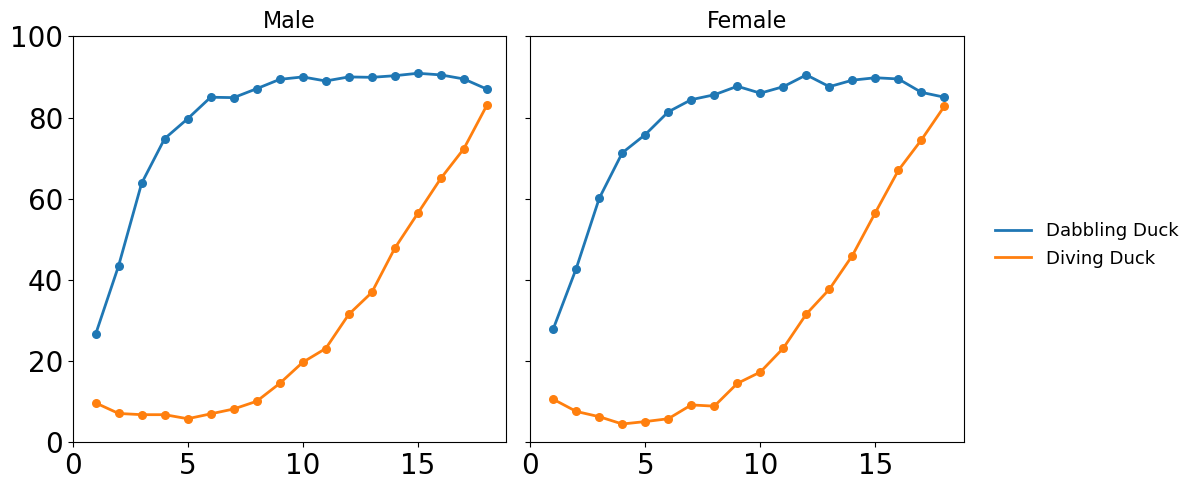

In [261]:
# Male and female on two plots
# With correction

def dict_to_df(prob_dict, label):
    return pd.DataFrame([
        {"time": t + 1, "species": species, "probability": prob * 100, "type": label}  # Multiply by 100 here
        for species, probs in prob_dict.items()
        for t, prob in enumerate(probs)
    ])

# Combine data
df_male = dict_to_df(prob_match_male_dict, "Male")
df_female = dict_to_df(prob_match_female_dict, "Female")
df_all = pd.concat([df_male, df_female])

# Legend order
priority_order = ['American Black Duck', 'Mallard', 'Gadwall']
# priority_order = []   # If compare dabbling and diving duck, comment out the line above and uncomment this line
remaining = sorted([sp for sp in prob_match_male_dict if sp not in priority_order])
legend_order = priority_order + remaining

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, match_type in zip(axes, ['Male', 'Female']):
    df = df_all[df_all["type"] == match_type]
    for i, species in enumerate(legend_order):
        group = df[df["species"] == species]
        ax.plot(group["time"], group["probability"], label=species if match_type == 'Male' else None, linewidth=2)
        ax.scatter(group["time"], group["probability"], s=30)

    # X and Y ticks
    ax.set_xticks([0, 5, 10, 15])
    ax.set_xticklabels([0, 5, 10, 15], fontsize=20)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=20)

    ax.set_title(match_type, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='center left', bbox_to_anchor=(0.82, 0.5),
    fontsize=13, frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


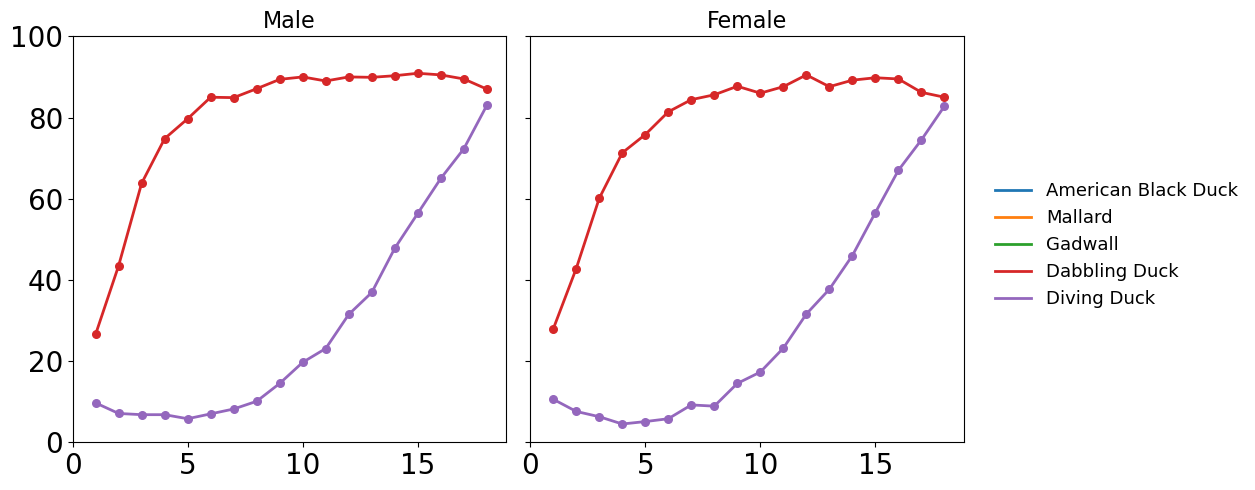

In [260]:
# Male and female on two plots
# Without correction

def dict_to_df(prob_dict, label):
    return pd.DataFrame([
        {"time": t + 1, "species": species, "probability": prob * 100, "type": label}  # Multiply by 100 here
        for species, probs in prob_dict.items()
        for t, prob in enumerate(probs)
    ])

# Combine data
df_male = dict_to_df(prob_male_uncorrected_dict, "Male")
df_female = dict_to_df(prob_female_uncorrected_dict, "Female")
df_all = pd.concat([df_male, df_female])

# Legend order
priority_order = ['American Black Duck', 'Mallard', 'Gadwall']
remaining = sorted([sp for sp in prob_match_male_dict if sp not in priority_order])
legend_order = priority_order + remaining

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, match_type in zip(axes, ['Male', 'Female']):
    df = df_all[df_all["type"] == match_type]
    for i, species in enumerate(legend_order):
        group = df[df["species"] == species]
        ax.plot(group["time"], group["probability"], label=species if match_type == 'Male' else None, linewidth=2)
        ax.scatter(group["time"], group["probability"], s=30)

    # X and Y ticks
    ax.set_xticks([0, 5, 10, 15])
    ax.set_xticklabels([0, 5, 10, 15], fontsize=20)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=20)

    ax.set_title(match_type, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='center left', bbox_to_anchor=(0.82, 0.5),
    fontsize=13, frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


#### Using Monte Carlo Integration Result:

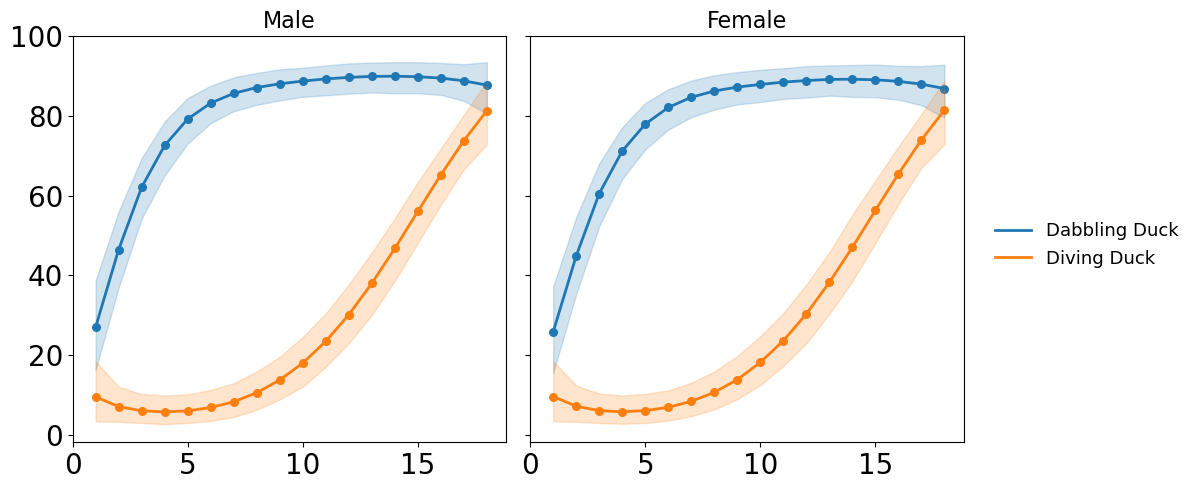

In [273]:
# Male and female on two side-by-side plots
# With correction

# Legend order (for the full model)
priority_order = ['American Black Duck', 'Mallard', 'Gadwall']
remaining = sorted([sp for sp in mean_male if sp not in priority_order])
legend_order = priority_order + remaining

# Legend order (for the reduced model)
legend_order = ['Dabbling Duck', 'Diving Duck']

# Color map
color_map = plt.get_cmap("tab10")
species_colors = {species: color_map(i % 10) for i, species in enumerate(legend_order)}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
week_range = np.arange(1, len(next(iter(mean_male.values()))) + 1)

for ax, match_type in zip(axes, ['Male', 'Female']):
    for species in legend_order:
        color = species_colors[species]

        if match_type == 'Male':
            mean = mean_male[species] * 100
            lower = ci_male_lower[species] * 100
            upper = ci_male_upper[species] * 100
        else:
            mean = mean_female[species] * 100
            lower = ci_female_lower[species] * 100
            upper = ci_female_upper[species] * 100

        # Plot mean line
        ax.plot(week_range, mean, color=color, label=species if match_type == 'Male' else None, linewidth=2)
        ax.scatter(week_range, mean, color=color, s=30)

        # Plot error band
        ax.fill_between(week_range, lower, upper, color=color, alpha=0.2)

    # Ticks and labels
    ax.set_xticks([0, 5, 10, 15])
    ax.set_xticklabels([0, 5, 10, 15], fontsize=20)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=20)

    ax.set_title(match_type, fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='center left', bbox_to_anchor=(0.82, 0.5),
    fontsize=13, frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


In [ ]:
# Male and female on the same plot
# With correciton
prob_match_male_dict = mean_male
prob_match_female_dict = mean_female

def dict_to_df(prob_dict, label):
    return pd.DataFrame([
        {"time": t + 1, "species": species, "probability": prob * 100, "type": label}
        for species, probs in prob_dict.items()
        for t, prob in enumerate(probs)
    ])

# Combine data
df_male = dict_to_df(prob_match_male_dict, "Male")
df_female = dict_to_df(prob_match_female_dict, "Female")
df_all = pd.concat([df_male, df_female])

# Legend order
priority_order = ['American Black Duck', 'Mallard', 'Gadwall']
remaining = sorted([sp for sp in prob_match_male_dict if sp not in priority_order])
legend_order = priority_order + remaining


species_list = legend_order
color_map = plt.get_cmap("tab10")
species_colors = {species: color_map(i % 10) for i, species in enumerate(species_list)}

# Plot
plt.figure(figsize=(15, 5))
for species in species_list:
    color = species_colors[species]

    # Male: solid
    male_group = df_all[(df_all["species"] == species) & (df_all["type"] == "Male")]
    plt.plot(
        male_group["time"], male_group["probability"],
        label=species, color=color, linewidth=2
    )
    plt.scatter(male_group["time"], male_group["probability"], s=30, color=color)

    # Female: dashed
    female_group = df_all[(df_all["species"] == species) & (df_all["type"] == "Female")]
    plt.plot(
        female_group["time"], female_group["probability"],
        linestyle='dashed', linewidth=2, color=color
    )
    plt.scatter(female_group["time"], female_group["probability"], s=30, color=color)

# Ticks and style
plt.xticks([0, 5, 10, 15], fontsize=20)
plt.yticks([0, 20, 40, 60, 80, 100], fontsize=20)
plt.xlabel("")
plt.ylabel("")
plt.grid(False)

# Legend
plt.legend(
    loc='center left', bbox_to_anchor=(0.99, 0.5),
    fontsize=13, frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


In [ ]:
# Female ducks
# Without correction and with correction
prob_female_uncorrected_dict = mean_female_uncorrected
prob_match_female_dict = mean_female


def dict_to_df(prob_dict, label):
    return pd.DataFrame([
        {"time": t + 1, "species": species, "probability": prob * 100, "type": label}
        for species, probs in prob_dict.items()
        for t, prob in enumerate(probs)
    ])

# Convert both versions to dataframes
df_uncorrected = dict_to_df(prob_female_uncorrected_dict, "Uncorrected")
df_corrected = dict_to_df(prob_match_female_dict, "Corrected")
df_all = pd.concat([df_uncorrected, df_corrected])

# Define species order
priority_order = ['American Black Duck', 'Mallard', 'Gadwall']
remaining = sorted([sp for sp in prob_match_female_dict if sp not in priority_order])
legend_order = priority_order + remaining

# Assign consistent colors per species
color_map = plt.get_cmap("tab10")
species_colors = {species: color_map(i % 10) for i, species in enumerate(legend_order)}

# Plot
plt.figure(figsize=(15, 5))

for species in legend_order:
    color = species_colors[species]

    # Uncorrected: solid
    df_u = df_all[(df_all["species"] == species) & (df_all["type"] == "Uncorrected")]
    plt.plot(
        df_u["time"], df_u["probability"],
        label=species, color=color, linewidth=2
    )
    plt.scatter(df_u["time"], df_u["probability"], s=30, color=color)

    # Corrected: dashed
    df_c = df_all[(df_all["species"] == species) & (df_all["type"] == "Corrected")]
    plt.plot(
        df_c["time"], df_c["probability"],
        linestyle='dashed', color=color, linewidth=2
    )
    plt.scatter(df_c["time"], df_c["probability"], s=30, color=color)

# Axes formatting
plt.xticks([0, 5, 10, 15], fontsize=20)
plt.yticks([0, 20, 40, 60, 80, 100], fontsize=20)
plt.xlabel("")
plt.ylabel("")
plt.grid(False)

# Shared legend
plt.legend(
    loc='center left', bbox_to_anchor=(0.99, 0.5),
    fontsize=13, frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


### Simulation: Perfect Matching on a Bipartite

In [ ]:
# Generate a bipartite graph
v1, v2 = 20, 20
edge_prob = 0.2
bg = BipartiteGraph(v1, v2, edge_prob=edge_prob, connected=True)

In [ ]:
# Construct the constraints based on the bipartite graph
tilde_A = np.zeros((bg.v1+bg.v2, bg.n_edges))
for i in range(bg.v1):
    for j, (u, v) in enumerate(bg.edges):
        if i == u:
            tilde_A[i, j] = 1

for i in range(bg.v1, bg.v1+bg.v2):
    for j, (u, v) in enumerate(bg.edges):
        if i == v:
            tilde_A[i, j] = 1

# # Perfect matching
# A = np.vstack([tilde_A, -tilde_A])
# b = np.vstack([np.ones((bg.v1+bg.v2, 1)), -np.ones((bg.v1+bg.v2, 1))])
# Matching
A = tilde_A
b = np.ones((bg.v1+bg.v2, 1))


In [ ]:
# Save A and b
np.savetxt(os.path.join(CONSTRAINT_DIR, f"Bipartite_Matching_m{A.shape[0]}_d{A.shape[1]}_A.csv"), A, fmt='%d')
np.savetxt(os.path.join(CONSTRAINT_DIR, f"Bipartite_Matching_m{b.shape[0]}_b.csv"), b, fmt='%d')



In [ ]:
# Generate Synthetic Data
n, d, p = 100, bg.n_edges, 20  # Number of observations, response dimension, predictor dimension
constraint = {"A": A, "b": b}  # Constraint: A y <= b

beta = np.random.randn(d, p)
gen = GenData(n=n, d=d, p=p, constraint=constraint, beta=beta, method_gen_X="BSpline", seed=2025)
data = gen.generate_data(verbose=True, method='latent', eta_variance=1)

# Print a summary of the generated data
print(gen.get_summary())
# Check if y truly satisfies the constraints
print(f"Check if y satisfies the constraints: {np.all(A @ data['y'].T <= b)}")

In [ ]:
np.savetxt("X.txt", data['X'].T, fmt="%f")
np.savetxt("y.txt", data['y'], fmt="%d")


In [ ]:
# Initialize Updater
tau = 1  # Precision for beta's prior
updater = Updater(data=data, tau=tau, constraint=constraint)

# MCMC Setup
n_iterations = 1000
burn_in = 200  # Number of iterations to discard as burn-in

n, p, d, m = updater.n, updater.p, updater.d, updater.m

zeta = updater.init_zeta  # Initialize zeta
u = updater.init_u  # Initialize u
#u = np.zeros((n, m))  # Initialize u
beta = np.random.randn(d, p)  # Initialize beta
# beta = gen.beta  # Use the true beta for initialization


zeta_samples = np.zeros((n_iterations, n, d))  # To store zeta samples
u_samples = np.zeros((n_iterations, n, m))  # To store u samples
beta_samples = np.zeros((n_iterations, d, p))  # To store beta samples

# Track acceptance rates
acceptance_rates = np.zeros(n_iterations)

In [ ]:
# Run MCMC with tqdm progress bar
for t in tqdm(range(n_iterations), desc="MCMC Sampling Progress"):    
    # Update zeta
    zeta, u, acc = updater.update_zeta_using_two_u(zeta, u, beta, nested_iter=[5, 1])
    zeta_samples[t] = zeta  # Store zeta samples
    u_samples[t] = u  # Store u samples
    acceptance_rates[t] = np.mean(acc)  # Store acceptance rate

    # Update beta
    beta = updater.update_beta(zeta)
    beta_samples[t] = beta  # Store beta samples

In [ ]:
# Run MCMC with tqdm progress bar
for t in tqdm(range(n_iterations), desc="MCMC Sampling Progress"):    
    # linear_predictor = (beta @ data["X"]).T  # Shape: n by d
    # Update zeta
    J = None # np.random.choice(np.arange(d), size=1, replace=False)
    zeta, u, u_in_region = updater.update_zeta_and_u(zeta, u, beta, J=J, nested_iter=5, simple_example=False)
    zeta_samples[t] = zeta  # Store zeta samples
    acceptance_rates[t] = np.mean(u_in_region)  # Store acceptance rate

    # Update beta
    beta = updater.update_beta(zeta)
    beta_samples[t] = beta  # Store beta samples

In [ ]:
# Adpatation for finding the mean of u
N_adapt = 1000
N_burnin_adapt = 500
sum_mu_u = np.zeros((n, m))
sum_accept = 0
for t in tqdm(range(N_adapt), desc="Adapting u"):
    beta = updater.update_beta(zeta)
    # linear_predictor = (beta @ data["X"]).T  # Shape: n by d
    zeta = updater.update_zeta(zeta, u, beta)[0]
    for _ in range(20):
        u = updater.update_u(zeta, u)
    # J = np.random.choice(np.arange(d), size=5)
    # zeta, u, accept = updater.update_zeta_and_u(zeta, u, beta,
    #                                             J = J,
    #                                             simple_example=False, nested_iter=5)
    
    if t >= N_burnin_adapt:
        sum_mu_u += u
        # sum_accept += np.mean(accept)
    
    

mu_u = sum_mu_u / (N_adapt - N_burnin_adapt)
# mean_accept = sum_accept / (N_adapt - N_burnin_adapt)
# print(f"Mean_accept: {mean_accept}")
# if mean_accept < 0.05:
#     print("Acceptance rate is too low. Please check the constraints.")
#     sys.exit()
print(f"mu_u: {mu_u}")

# Run MCMC with tqdm progress bar
for t in tqdm(range(n_iterations), desc="MCMC Sampling Progress"):    
    

    linear_predictor = (beta @ data["X"]).T  # Shape: n by d
    # Update zeta
    # mu_u, std_u = updater.update_u_using_SVM(linear_predictor)
    zeta, u_in_region = updater.update_zeta_with_u_auxiliary(mu_u, 1, zeta, linear_predictor)
    zeta_samples[t] = zeta  # Store zeta samples
    acceptance_rates[t] = np.mean(u_in_region)  # Store acceptance rate

    # Update beta
    beta = updater.update_beta(zeta)
    beta_samples[t] = beta  # Store beta samples

    

    
    

In [ ]:
### MCMC Analysis
Analyzer = {}  # Dictionary to store MCMCAnalysis objects
Parameter_names = ['zeta', 'u', 'beta']
Parameter_samples = {
    'zeta': zeta_samples,
    'u': u_samples,
    'beta': beta_samples
}

# Create MCMCAnalysis objects for each parameter
for name in Parameter_names:
    samples = Parameter_samples[name]
    Analyzer[name] = MCMCAnalysis(samples, burn_in=burn_in, param_name=name)

In [ ]:
# Mean Squared Error (MSE) between the posterior means of beta and the true beta
print("Mean Squared Error (MSE) for beta estimation:")
print(Analyzer['beta'].MSE(gen.beta))

# Posterior means of beta
print("\nPosterior means of beta (estimated):")
print(Analyzer['beta'].posterior_means())

# True beta values used for data generation
print("\nTrue beta values (ground truth):")
print(gen.beta)

# # Compare the posterior means and true beta visually
# print("\nComparison of True and Estimated Beta:")
# for i in range(gen.d):
#     for j in range(gen.p):
#         print(f"Beta[{i},{j}]: True = {gen.beta[i, j]:.4f}, Estimated = {Analyzer['beta'].posterior_means()[i, j]:.4f}")


In [ ]:
# Correct computation of estimated linear predictor
estimated_linear_predictor = (Analyzer['beta'].posterior_means() @ gen.X). T  # Shape: (n, d)
true_linear_predictor = gen.linear_predictor
print(f"MSE for linear predictor is {np.mean((estimated_linear_predictor - true_linear_predictor) ** 2)}")

xx=2
fig, axes = plt.subplots(1, xx, figsize=(18, 6))  # 1 row, 2 columns
for j in range(xx):  # Loop over the two dimensions
    axes[j].plot(range(gen.n), gen.linear_predictor[:, j], label=f"True Predictor Dim {j+1}", color="blue")
    axes[j].plot(range(gen.n), estimated_linear_predictor[:, j], linestyle="--", label=f"Estimated Predictor Dim {j+1}", color="red")
    axes[j].set_title(f"Comparison of True and Estimated Linear Predictors (Dim {j+1})")
    axes[j].set_xlabel("Observation Index")
    axes[j].set_ylabel("Linear Predictor Value")
    axes[j].legend()
    axes[j].grid(True)

plt.tight_layout()
plt.show()



In [ ]:
# Verify the constraints
print("Check if the constraints are satisfied:")
est_zeta = Analyzer['zeta'].posterior_means()
A = updater.A
b = updater.b
all_good = True
for i in range(n):
    est_y = linprog(est_zeta[i,:], A_ub=A, b_ub=b).x
    if not np.all(A @ est_y <= b):
        print(f"Constraint not satisfied for observation {i}.")
        all_good = False
if all_good:
    print("All constraints are satisfied.")


### Run a simple simulation

In [141]:
# Generate Synthetic Data
n, d, p = 1000, 2, 2  # Number of observations, response dimension, predictor dimension
constraint = {"A": np.array([[1,1]], dtype=int), "b": np.array([1])}  # Constraint: A y <= b

beta = np.random.randn(d, p)
X = np.hstack([np.ones((n, 1)), np.linspace(-5,5,num=n).reshape(n,1)]).T  # Design matrix with intercept
gen = GenData(n=n, d=d, p=p, constraint=constraint, beta=beta, X=X, seed=2024)
data = gen.generate_data(verbose=False, method='latent', eta_variance=1)

# Print a summary of the generated data
print(gen.get_summary())

Data Summary:
  - Number of observations (n): 1000
  - Dimensionality of responses (d): 2
  - Number of predictors (p): 2
  - Constraint applied: Yes
  - Constraint shape: A((1, 2)), b(1)



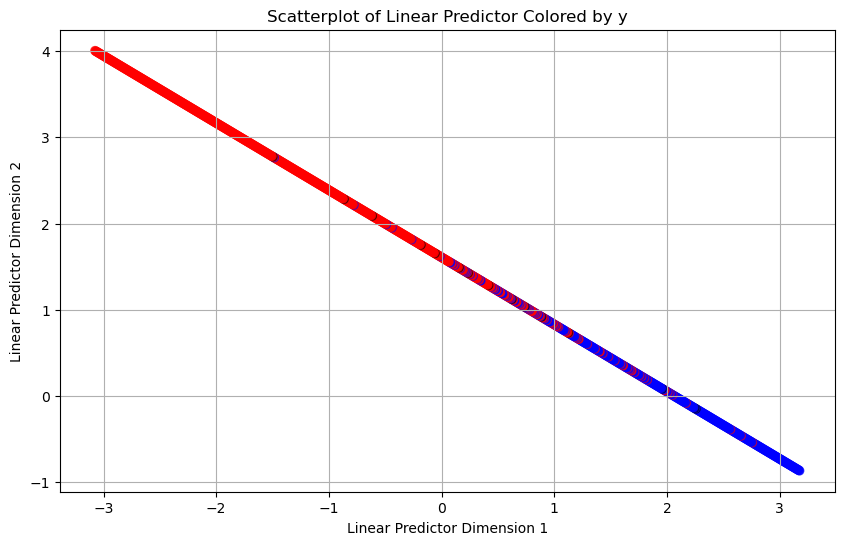

In [142]:
# Scatterplot coloring based on y
colors = {"[1 0]": "blue", "[0 1]": "red", "[0 0]": "black"}  # Color mapping
color_labels = [colors[str(yi)] for yi in data['y']]

# Plot scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(gen.linear_predictor[:, 0], gen.linear_predictor[:, 1], c=color_labels, alpha=0.7)
plt.title("Scatterplot of Linear Predictor Colored by y")
plt.xlabel("Linear Predictor Dimension 1")
plt.ylabel("Linear Predictor Dimension 2")
plt.grid(True)
plt.show()

In [143]:
# Prediction function based on closed-form rules
def predict_y_hat(zeta):
    """
    Predict y_hat based on the closed-form rules.
    """
    n, d = zeta.shape
    y_hat = np.zeros((n, d), dtype=int)

    condition_1 = (zeta[:, 0] < 0) & (zeta[:, 1] < 0)  # Both z1 < 0 and z2 < 0
    condition_2 = (zeta[:, 0] < zeta[:, 1]) & (zeta[:, 1] > 0)  # z1 < z2 and z2 > 0
    condition_3 = ~(condition_1 | condition_2)  # Remaining cases

    y_hat[condition_1] = [0, 0]
    y_hat[condition_2] = [0, 1]
    y_hat[condition_3] = [1, 0]

    return y_hat


# Add prediction testing to the simulation
def test_prediction(updater, zeta, true_y):
    """
    Test the accuracy of predictions based on the current zeta.
    """
    y_hat = predict_y_hat(zeta)
    accuracy = accuracy_score(true_y.flatten(), y_hat.flatten())
    return accuracy, y_hat

In [150]:
# Initialize Updater
tau = 10  # Variance for beta's prior
updater = Updater(data=data, tau=tau, constraint=constraint)
updater2 = Updater(data=data, tau=tau, constraint=constraint)

# MCMC Setup
n_iterations = 10000
burn_in = 5000  # Number of iterations to discard as burn-in

n, p, d, m = updater.n, updater.p, updater.d, updater.m

zeta = updater.init_zeta  # Initialize zeta
beta = np.zeros((d, p))  # Initialize beta

beta_samples_augmented = np.zeros((n_iterations, d, p))  # To store beta samples
beta_samples_probit = np.zeros((n_iterations, d, p))  # To store beta samples



In [151]:
# Run MCMC with tqdm progress bar
zeta = updater.init_zeta  # Initialize zeta
beta = np.zeros((d, p))  # Initialize beta
for t in tqdm(range(n_iterations), desc="MCMC Sampling Progress"):
    # Update zeta
    zeta = updater.update_zeta_for_simple_example(beta, zeta)
    
    # Update beta
    beta = updater.update_beta(zeta)


    beta_samples_augmented[t] = beta  # Store beta samples

    

MCMC Sampling Progress: 100%|██████████| 10000/10000 [00:12<00:00, 810.14it/s]


In [158]:
# Run MCMC with tqdm progress bar
beta = np.zeros((d, p))  # Initialize beta
for t in tqdm(range(n_iterations), desc="MCMC Sampling Progress"):
    # Update zeta
    zeta = updater2.update_zeta_unconstrained_simple_example(beta)
    
    # Update beta
    beta = updater.update_beta(zeta)


    beta_samples_probit[t] = beta  # Store beta samples

    

MCMC Sampling Progress: 100%|██████████| 10000/10000 [00:05<00:00, 1892.99it/s]


In [221]:
### MCMC Analysis
Analyzer = {}  # Dictionary to store MCMCAnalysis objects
Parameter_names = ['beta']
Parameter_samples = {
    'beta': beta_samples_augmented
}

# Create MCMCAnalysis objects for each parameter
for name in Parameter_names:
    samples = Parameter_samples[name]
    Analyzer[name] = MCMCAnalysis(samples, burn_in=burn_in, param_name=name, ground_truth=gen.beta)

Initialized MCMCAnalysis for beta:
- Total iterations: 10000
- Burn-in: 5000
- Post burn-in iterations: 5000
- Dimension 1 (dim1): 2
- Dimension 2 (dim2): 2


In [222]:
# Mean Squared Error (MSE) between the posterior means of beta and the true beta
print("RMSE for beta estimation:")
print(sqrt(Analyzer['beta'].MSE()))

# Posterior means of beta
print("\nPosterior means of beta (estimated):")
print(Analyzer['beta'].posterior_means())

# True beta values used for data generation
print("\nTrue beta values (ground truth):")
print(gen.beta)

# Compare the posterior means and true beta visually
print("\nComparison of True and Estimated Beta:")
for i in range(gen.d):
    for j in range(gen.p):
        print(f"Beta[{i},{j}]: True = {gen.beta[i, j]:.4f}, Estimated = {Analyzer['beta'].posterior_means()[i, j]:.4f}")


RMSE for beta estimation:
0.06072046982341808

Posterior means of beta (estimated):
[[ 0.07821734 -0.59935911]
 [ 1.46597219  0.43615346]]

True beta values (ground truth):
[[ 0.05013661 -0.62510347]
 [ 1.56946739  0.48699976]]

Comparison of True and Estimated Beta:
Beta[0,0]: True = 0.0501, Estimated = 0.0782
Beta[0,1]: True = -0.6251, Estimated = -0.5994
Beta[1,0]: True = 1.5695, Estimated = 1.4660
Beta[1,1]: True = 0.4870, Estimated = 0.4362


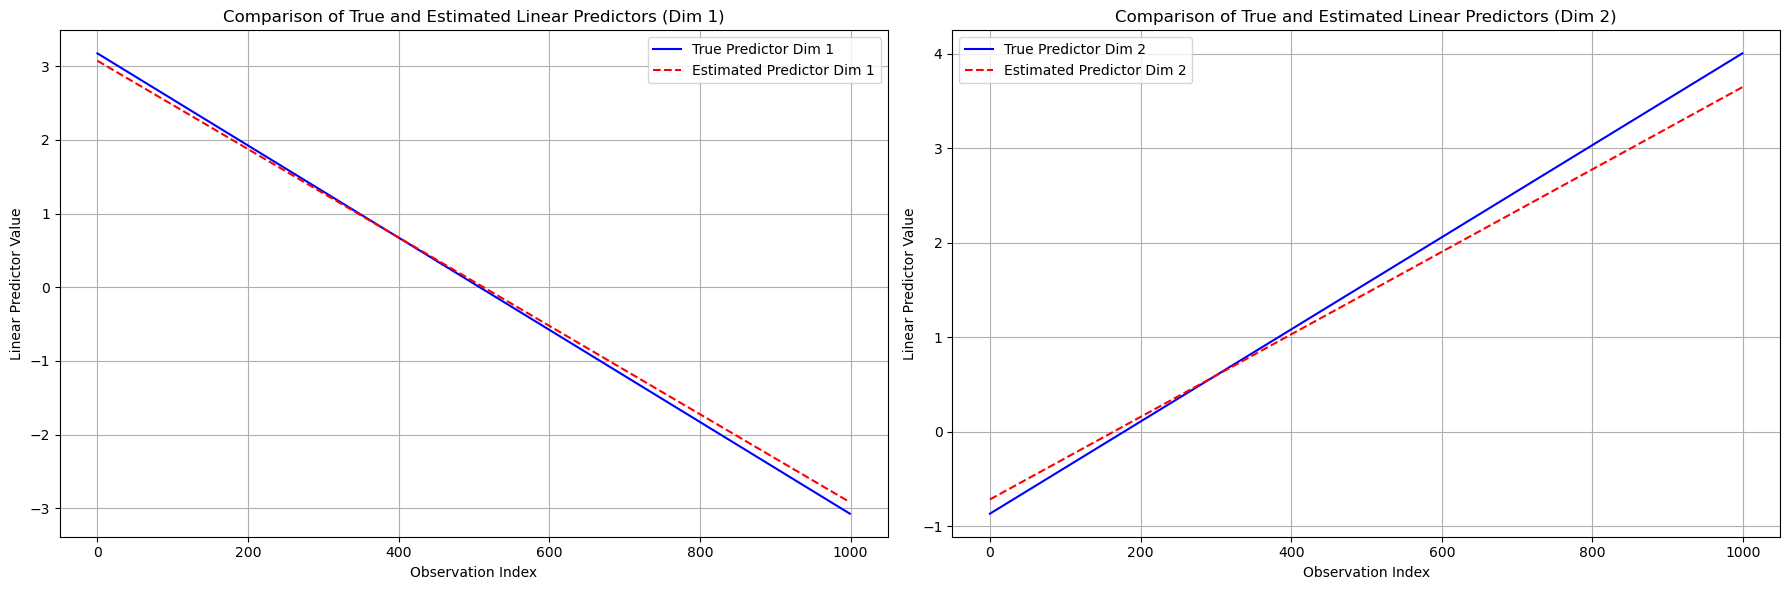

In [223]:
# Correct computation of estimated linear predictor
estimated_linear_predictor = (Analyzer['beta'].posterior_means() @ gen.X). T  # Shape: (n, d)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))  # 1 row, 2 columns
for j in range(2):  # Loop over the two dimensions
    axes[j].plot(range(gen.n), gen.linear_predictor[:, j], label=f"True Predictor Dim {j+1}", color="blue")
    axes[j].plot(range(gen.n), estimated_linear_predictor[:, j], linestyle="--", label=f"Estimated Predictor Dim {j+1}", color="red")
    axes[j].set_title(f"Comparison of True and Estimated Linear Predictors (Dim {j+1})")
    axes[j].set_xlabel("Observation Index")
    axes[j].set_ylabel("Linear Predictor Value")
    axes[j].legend()
    axes[j].grid(True)

plt.tight_layout()
plt.show()



### MCMC Samples Analysis (Probit)

In [163]:
def ilp_map_batch(c_matrix):
    """
    Vectorized version of ilp_map for d = 2.

    Parameters:
    - c_matrix: (n_samples, 2) array of simulated latent variables

    Returns:
    - y_matrix: (n_samples, 2) array of binary outputs
    """
    y = np.zeros_like(c_matrix, dtype=int)

    # First condition: c[0] > max(c[1], 0)
    cond1 = c_matrix[:, 0] > np.maximum(c_matrix[:, 1], 0)
    y[cond1, 0] = 1

    # Second condition: c[1] > max(c[0], 0)
    cond2 = c_matrix[:, 1] > np.maximum(c_matrix[:, 0], 0)
    y[cond2, 1] = 1

    return y


# ----------------------------------------
# Helper function to simulate conditional ILP-mapped probabilities
# ----------------------------------------
def compute_ilp_probs(mu, n_sim=10000):
    """
    Simulates from N(mu, I_d) and estimates probabilities for each binary outcome
    using the vectorized ILP mapping.
    """
    zeta_sim = np.random.randn(n_sim, len(mu)) + mu  # shape: (n_sim, d)
    y_sim = ilp_map_batch(zeta_sim)
    return {
        "(1,0)": np.mean(np.all(y_sim == [1, 0], axis=1)),
        "(0,1)": np.mean(np.all(y_sim == [0, 1], axis=1)),
        "(1,1)": np.mean(np.all(y_sim == [1, 1], axis=1)),
        "(0,0)": np.mean(np.all(y_sim == [0, 0], axis=1)),
    }





In [212]:
# read_dir = os.path.join(RESULT_DIR, "Probit")

# # -------------------------------
# # Load Data
# # -------------------------------

# def read_rds_array(path):
#     return np.array(pyreadr.read_r(path)[None])

# beta_true = read_rds_array(os.path.join(read_dir, "beta_true.rds"))        # (p, d)
# beta_samples_probit = read_rds_array(os.path.join(read_dir, "beta_samples_probit.rds"))  # (iter, p, d)
# beta_samples_augmented = read_rds_array(os.path.join(read_dir, "beta_samples_augmented.rds"))  # (iter, p, d)
# X = read_rds_array(os.path.join(read_dir, "X.rds"))                        # (n, p)
# y = read_rds_array(os.path.join(read_dir, "y.rds"))                        # (n, d)



beta_true = gen.beta.T
X = data['X'].T
y = data['y']


# -------------------------------
# Posterior Mean
# -------------------------------

thin_start = 2000
thin_step = 10
beta_post_mean_probit = np.mean(beta_samples_probit[thin_start::thin_step], axis=0).T
beta_post_mean_augmented = np.mean(beta_samples_augmented[thin_start::thin_step], axis=0).T

n, p = X.shape
d = y.shape[1]

# -------------------------------
# Predicted Probabilities: Probit
# -------------------------------

mu_probit = X @ beta_post_mean_probit
prob = norm.cdf(mu_probit)

df_pred = pd.DataFrame({
    "x": X[:, 1],
    "(0,0)": (1 - prob[:, 0]) * (1 - prob[:, 1]),
    "(1,0)": prob[:, 0] * (1 - prob[:, 1]),
    "(0,1)": (1 - prob[:, 0]) * prob[:, 1],
    "(1,1)": prob[:, 0] * prob[:, 1],
})

# -------------------------------
# Predicted Probabilities: Augmented (ILP)
# -------------------------------

mu_aug = X @ beta_post_mean_augmented
prob_dict_aug = {k: [] for k in ["(0,0)", "(1,0)", "(0,1)", "(1,1)"]}

for i in range(n):
    if i % 100 == 0:
        print(f"[Augmented] Simulating for row {i}")
    probs = compute_ilp_probs(mu_aug[i], n_sim=10000)
    for key in prob_dict_aug:
        prob_dict_aug[key].append(probs[key])

df_pred_aug = pd.DataFrame({
    "x": X[:, 1],
    **prob_dict_aug
})

# -------------------------------
# Predicted Probabilities: Ground Truth
# -------------------------------

mu_true = X @ beta_true
prob_dict_true = {k: [] for k in ["(0,0)", "(1,0)", "(0,1)", "(1,1)"]}

for i in range(n):
    if i % 100 == 0:
        print(f"[Ground Truth] Simulating for row {i}")
    probs = compute_ilp_probs(mu_true[i], n_sim=10000)
    for key in prob_dict_true:
        prob_dict_true[key].append(probs[key])

df_pred_true = pd.DataFrame({
    "x": X[:, 1],
    **prob_dict_true
})




[Augmented] Simulating for row 0
[Augmented] Simulating for row 100
[Augmented] Simulating for row 200
[Augmented] Simulating for row 300
[Augmented] Simulating for row 400
[Augmented] Simulating for row 500
[Augmented] Simulating for row 600
[Augmented] Simulating for row 700
[Augmented] Simulating for row 800
[Augmented] Simulating for row 900
[Ground Truth] Simulating for row 0
[Ground Truth] Simulating for row 100
[Ground Truth] Simulating for row 200
[Ground Truth] Simulating for row 300
[Ground Truth] Simulating for row 400
[Ground Truth] Simulating for row 500
[Ground Truth] Simulating for row 600
[Ground Truth] Simulating for row 700
[Ground Truth] Simulating for row 800
[Ground Truth] Simulating for row 900


In [213]:
from scipy.interpolate import UnivariateSpline

def smooth_df_probs(df, smoothness=1):
    """
    Smooth each probability column as a function of x using splines,
    and renormalize so each row sums to ~1.
    """
    df_smoothed = df.copy()
    x = df['x'].values

    # Apply smoothing to each class column
    for col in df.columns[1:]:
        y = df[col].values
        spline = UnivariateSpline(x, y, s=smoothness)
        df_smoothed[col] = spline(x)

    # Optional: renormalize each row to ensure sum ~ 1
    prob_matrix = df_smoothed.iloc[:, 1:].values
    row_sums = prob_matrix.sum(axis=1, keepdims=True)
    prob_matrix = prob_matrix / row_sums

    df_smoothed.iloc[:, 1:] = prob_matrix
    return df_smoothed


In [217]:
# Get the smooth version for better visualization
df_pred_aug_s = smooth_df_probs(df_pred_aug, smoothness=0.008)
df_pred_true_s = smooth_df_probs(df_pred_true, smoothness=0.008)


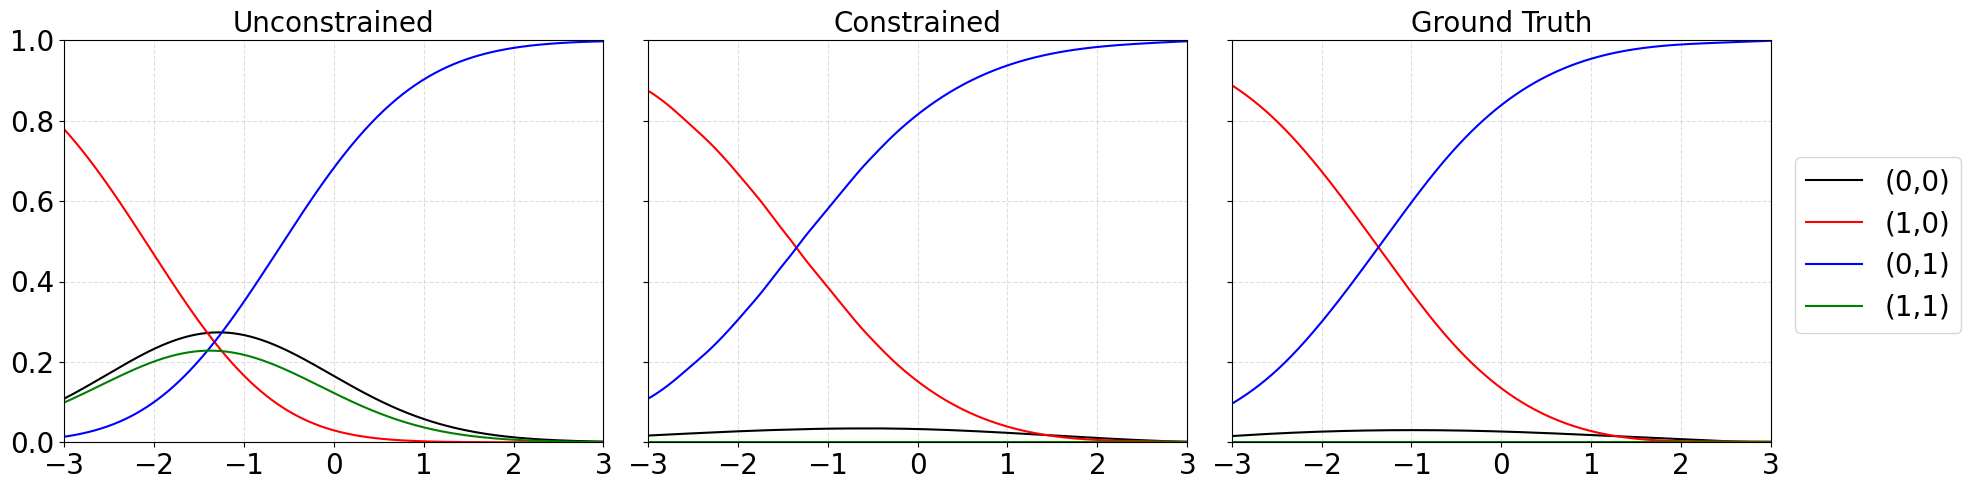

In [218]:
# === Assumes you already have: df_pred, df_pred_aug, df_pred_true, X, y ===
# Example: df_pred = pd.DataFrame({ 'x': ..., '(0,0)': ..., '(1,0)': ..., '(0,1)': ..., '(1,1)': ... })

# Compute observed class strings and vertical positions
y_class_str = np.array(["({},{})".format(int(i), int(j)) for i, j in y])
y_class_pos = {"(0,0)": 0.8, "(1,0)": 0.85, "(0,1)": 0.9, "(1,1)": 0.95}
y_pos = np.array([y_class_pos[c] for c in y_class_str])
color_map = {"(0,0)": "black", "(1,0)": "red", "(0,1)": "blue", "(1,1)": "green"}
dot_colors = np.array([color_map[c] for c in y_class_str])

# Set up a 3-panel horizontal plot layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Define reusable plotting function
def plot_probs_with_observed(ax, df, title):
    ax.plot(df["x"], df["(0,0)"], label="(0,0)", color="black")
    ax.plot(df["x"], df["(1,0)"], label="(1,0)", color="red")
    ax.plot(df["x"], df["(0,1)"], label="(0,1)", color="blue")
    ax.plot(df["x"], df["(1,1)"], label="(1,1)", color="green")
    # ax.scatter(X[:, 1], y_pos, color=dot_colors, s=20, alpha=0.6)
    ax.set_title(title, fontsize=20)
    # ax.set_xlabel(rf"$x$", fontsize=20)
    ax.set_xlim([-3, 3])
    ax.set_ylim([0, 1])
    ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
    ax.tick_params(axis='x', labelsize=20)      
    ax.tick_params(axis='y', labelsize=20)      
    ax.grid(True, linestyle="--", alpha=0.4)


# Draw each panel
plot_probs_with_observed(axes[0], df_pred, "Unconstrained")
plot_probs_with_observed(axes[1], df_pred_aug_s, "Constrained")
plot_probs_with_observed(axes[2], df_pred_true_s, "Ground Truth")

# # Shared y-axis label
# axes[0].set_ylabel("Predicted Probability")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="right", ncol=1, bbox_to_anchor=(1.1, 0.5), fontsize=20)

plt.tight_layout()
plt.show()


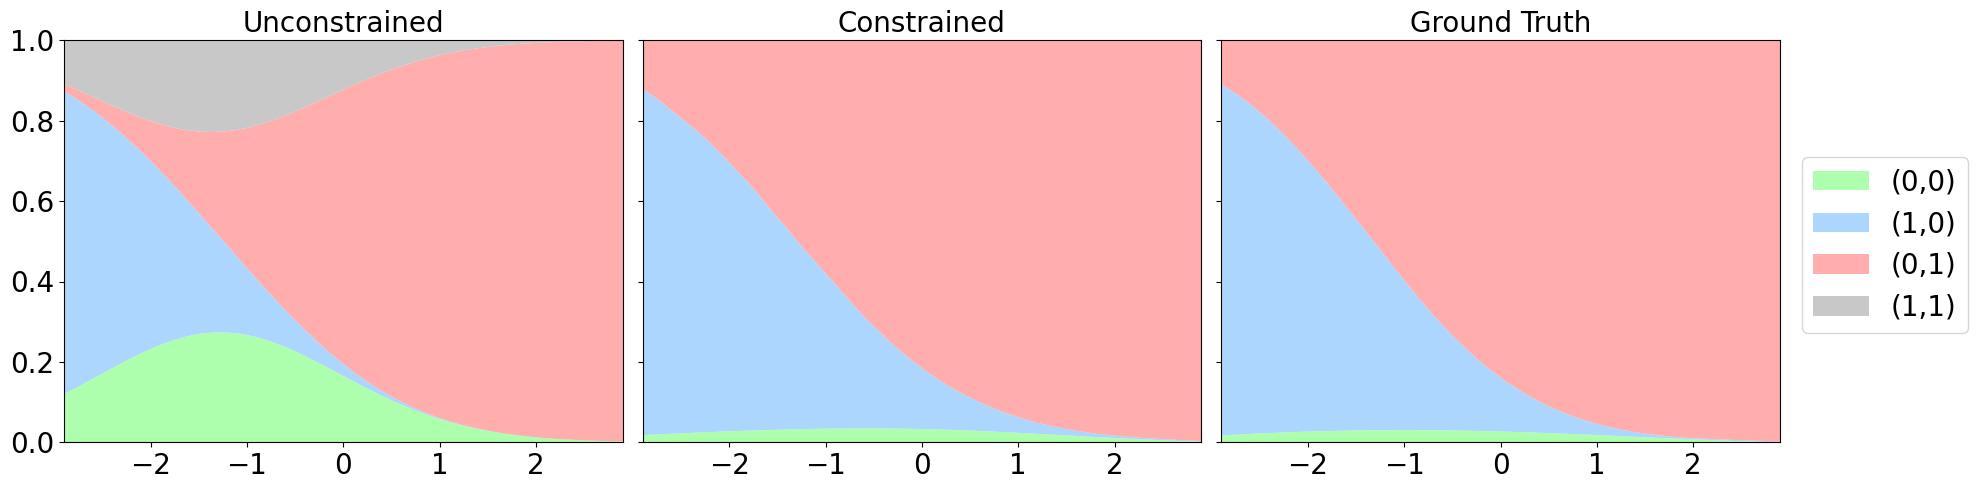

In [227]:

# Melt wide dataframes to long format
df_pred_long = df_pred.melt(id_vars="x", var_name="Y", value_name="prob")
df_pred_aug_long = df_pred_aug_s.melt(id_vars="x", var_name="Y", value_name="prob")
df_pred_true_long = df_pred_true_s.melt(id_vars="x", var_name="Y", value_name="prob")

# Add Method labels
df_pred_long["Method"] = "Unconstrained"
df_pred_aug_long["Method"] = "Constrained"
df_pred_true_long["Method"] = "Ground Truth"

# Combine into one long-form dataframe
df_all = pd.concat([df_pred_long, df_pred_aug_long, df_pred_true_long], ignore_index=True)

# Function to pivot and prepare data for stacking
def prepare_stacked(df_method):
    df_sorted = df_method.sort_values("x")
    df_pivot = df_sorted.pivot(index="x", columns="Y", values="prob").fillna(0)
    # Ensure column order
    df_pivot = df_pivot[["(0,0)", "(1,0)", "(0,1)", "(1,1)"]]
    return df_pivot

# Setup plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
methods = ["Unconstrained", "Constrained", "Ground Truth"]
long_dfs = [df_pred_long, df_pred_aug_long, df_pred_true_long]
colors = ["#99ff99", "#99ccff", "#ff9999", "#bbbbbb"]

for ax, method, df_method in zip(axes, methods, long_dfs):
    df_method = df_method[df_method["Method"] == method]
    df_stacked = prepare_stacked(df_method)
    x_vals = df_stacked.index.values
    y_vals = df_stacked.values.T  # shape: (4, n_points)
    
    ax.stackplot(x_vals, y_vals, labels=df_stacked.columns, colors=colors, alpha=0.8)
    ax.set_title(method, fontsize=20)
    # ax.set_xlabel("X[:, 1]")
    ax.set_xlim([-2.9, 2.9])
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.grid(False)

# axes[0].set_ylabel("Predicted Probability")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center", ncol=1, bbox_to_anchor=(1.05, 0.5), fontsize=20)

plt.tight_layout()
plt.show()
